In [1]:
# NPGA (ES gradients) with phi sampled from Drive CSV
# Two payment scenarios:
#   (A) Uniform market-clearing price (all winners paid p* = marginal accepted bid)
#   (B) Pay-as-bid (each winner paid own bid)
# Allocation: accept lowest bids until demand is met; capacity per supplier; bids above price cap are rejected.
# Utility: u_i = q_i_alloc * (payment_i - v_i) if accepted else 0.

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
#from google.colab import drive
import ast
import torch.nn.functional as F
from typing import Dict, Any
from typing import Dict, Any, List, Optional, Tuple
import numpy as np
import pandas as pd
import ast

## lo ultimo que hice fue tormar el median

In [2]:
import sys, torch
print(sys.version)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
2.5.1+cu121
12.1
True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


## PARTE 0: CARGAR DATOS

In [3]:

# =========================
# 0) Load CSV from Drive
# =========================
#drive.mount("/content/drive")
CSV_PATH = "../../results/fechas_117/TERMICA/inputRed2.csv"   # <-- adjust
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal="."     # si tienes 1.234.567,89
)
df.columns = df.columns.str.strip() 
df=df.sort_values(["Fecha", "id_planta"]).reset_index(drop=True)
required = ['id_planta', "available_q", "phi", "precio_d", "daily_reman_demand"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

# Optional: if present, enables per-player phi sampling
AGENT_COL = "id_planta" if "id_planta" in df.columns else None


# =========================
# 1) Device / seeds
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(">>> Running on device:", device)

torch.manual_seed(0)
np.random.seed(0)

TensorDict = Dict[str, torch.Tensor]

>>> Running on device: cuda


In [4]:
#df[(df['id_planta'] == 2) & (df['cluster']=='        ')]

## Cargar datos

In [5]:
import numpy as np
import pandas as pd
import ast


def _parse_available_q_24(x, *, fill_value=np.nan) -> np.ndarray:
    """
    Convierte available_q a vector (24,).
    Soporta: lista/np.array, string tipo "[...]", escalar, NaN.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.full(24, float(fill_value), dtype=float)

    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "nan":
            return np.full(24, float(fill_value), dtype=float)
        # intenta parsear lista
        if s.startswith("[") and s.endswith("]"):
            x = ast.literal_eval(s)
        else:
            # escalar en string
            try:
                val = float(s)
                return np.full(24, val, dtype=float)
            except Exception:
                return np.full(24, float(fill_value), dtype=float)

    if isinstance(x, (list, tuple, np.ndarray)):
        a = np.asarray(x, dtype=float).reshape(-1)
        if a.size == 24:
            return a
        if a.size == 1:
            return np.full(24, float(a[0]), dtype=float)
        raise ValueError(f"available_q debe ser len=24 o escalar; got len={a.size}")

    # escalar numérico
    try:
        val = float(x)
        return np.full(24, val, dtype=float)
    except Exception:
        return np.full(24, float(fill_value), dtype=float)


def _kmeans_numpy(X: np.ndarray, k: int, *, seed: int = 123, max_iter: int = 200, tol: float = 1e-6):
    """
    K-means (numpy puro). X sin NaN. Retorna labels (n,) y centers (k,d).
    """
    rng = np.random.default_rng(int(seed))
    n, d = X.shape
    if not (1 <= k <= n):
        raise ValueError(f"G debe estar en [1,n]. G={k}, n={n}")

    # kmeans++ init
    centers = np.empty((k, d), dtype=float)
    i0 = int(rng.integers(0, n))
    centers[0] = X[i0]
    dist2 = np.sum((X - centers[0]) ** 2, axis=1)

    for j in range(1, k):
        s = dist2.sum()
        p = dist2 / s if s > 0 else np.full(n, 1.0 / n)
        ij = int(rng.choice(n, p=p))
        centers[j] = X[ij]
        dist2 = np.minimum(dist2, np.sum((X - centers[j]) ** 2, axis=1))

    labels = np.zeros(n, dtype=int)

    for _ in range(int(max_iter)):
        D = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)  # (n,k)
        new_labels = np.argmin(D, axis=1)

        new_centers = centers.copy()
        for j in range(k):
            idx = np.where(new_labels == j)[0]
            if idx.size == 0:
                new_centers[j] = X[int(rng.integers(0, n))]
            else:
                new_centers[j] = X[idx].mean(axis=0)

        shift = float(np.max(np.abs(new_centers - centers)))
        centers = new_centers
        labels = new_labels
        if shift < tol:
            break

    return labels, centers



def crear_columna_grupo(
    df: pd.DataFrame,
    *,
    G: int,
    id_col: str = "id_planta",
    precio_col: str = "precio_d",
    seed: int = 123,
) -> tuple[pd.DataFrame, dict[int, int]]:
    """
    Crea df["Grupo"] ∈ {1,...,G}, asignado por planta (id_planta),
    usando SOLO precio_d (bids).

    Features por planta:
      - precio_d: mediana y std usando todas las observaciones finitas
    """

    req = [id_col, precio_col]
    miss = [c for c in req if c not in df.columns]
    if miss:
        raise KeyError(f"Faltan columnas requeridas: {miss}")

    d = df.copy()

    # --- precio_d ---
    p_num = pd.to_numeric(d[precio_col], errors="coerce")
    p_df = pd.DataFrame({id_col: d[id_col].values, "p": p_num.values})
    p_df = p_df[np.isfinite(p_df["p"].values)]

    p_stats = (
        p_df.groupby(id_col, as_index=False)["p"]
            .agg(p_median="median", p_std="std")
    )
    p_stats["p_std"] = p_stats["p_std"].fillna(0.0)

    # --- matriz de features por planta ---
    base = pd.DataFrame({id_col: pd.unique(d[id_col].values)})
    feats = base.merge(p_stats, on=id_col, how="left")

    # imputación coherente
    if feats["p_median"].notna().any():
        feats["p_median"] = feats["p_median"].fillna(feats["p_median"].median())
    else:
        feats["p_median"] = feats["p_median"].fillna(0.0)

    feats["p_std"] = feats["p_std"].fillna(0.0)

    X = feats[["p_median", "p_std"]].to_numpy(dtype=float)

    # NaN/inf -> mediana columna
    col_med = np.nanmedian(X, axis=0)
    bad = ~np.isfinite(X)
    if bad.any():
        X[bad] = col_med[np.where(bad)[1]]

    # estandarización
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd == 0] = 1.0
    Xz = (X - mu) / sd

    # k-means
    n_plants = Xz.shape[0]
    G_eff = int(min(int(G), n_plants)) if n_plants > 0 else 0
    if G_eff <= 0:
        d["Grupo"] = pd.Series([pd.NA] * len(d), dtype="Int64")
        return d, {}

    labels0, _ = _kmeans_numpy(Xz, G_eff, seed=int(seed))
    grupos = (labels0 + 1).astype(int)

    gid_by_pid = {
        int(pid): int(g)
        for pid, g in zip(feats[id_col].to_numpy(), grupos)
    }

    d["Grupo"] = d[id_col].map(gid_by_pid).astype("Int64")

    return d, gid_by_pid

In [6]:
def _aq24(x):
    if pd.isna(x):
        return np.full(24, np.nan)
    if isinstance(x, str):
        x = ast.literal_eval(x)
    a = np.asarray(x, float).reshape(-1)
    if a.size == 24:
        return a
    return np.full(24, float(a[0]) if a.size else np.nan)

def mean_por_hora_y_precio(df, grupo=None):
    grupo = grupo or ("Grupo" if "Grupo" in df.columns else "cluster")

    A = np.vstack(df["available_q"].apply(_aq24))  # (n,24)
    tmp = pd.concat(
        [
            df[[grupo]].rename(columns={grupo: "Grupo"}).reset_index(drop=True),
            pd.DataFrame(A, columns=[f"h{h+1}" for h in range(24)]),
            pd.to_numeric(df["precio_d"], errors="coerce").rename("precio_d").reset_index(drop=True),
        ],
        axis=1,
    )

    out = tmp.groupby("Grupo").mean(numeric_only=True).reset_index()
    return out[["Grupo"] + [f"h{i}" for i in range(1, 25)] + ["precio_d"]]

In [7]:
def mean_por_planta_y_hora(df, grupo=None):
    """
    Calcula el promedio horario (h1-h24) y precio por id_planta dentro de cada grupo/cluster.

    Args:
        df: dataframe que contiene columnas 'available_q', 'id_planta', 'precio_d', y 'cluster' o 'Grupo'.
        grupo: columna de agrupamiento (cluster o Grupo). Si no se da, busca 'Grupo' o 'cluster'.

    Returns:
        DataFrame con columnas: Grupo | id_planta | h1-h24 | precio_d
    """
    grupo = grupo or ("Grupo" if "Grupo" in df.columns else "cluster")

    # parse available_q -> (n,24)
    A = np.vstack(df["available_q"].apply(_parse_available_q_24).values)

    tmp = pd.concat(
        [
            df[[grupo, "id_planta"]].rename(columns={grupo: "Grupo"}).reset_index(drop=True),
            pd.DataFrame(A, columns=[f"h{i+1}" for i in range(24)]),
            pd.to_numeric(df["precio_d"], errors="coerce").rename("precio_d").reset_index(drop=True),
        ],
        axis=1,
    )

    # mean por id_planta dentro de cada Grupo
    out = (
        tmp
        .groupby(["Grupo", "id_planta"], as_index=False)
        .mean(numeric_only=True)
    )

    return out

In [8]:
import torch

def resolve_device_str(device="auto") -> str:
    if device == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return str(device)


In [9]:
def get_torch_device(device: str = "auto") -> torch.device:
    """
    device:
      - "auto": cuda si disponible, si no cpu
      - "cuda": fuerza cuda (error si no hay)
      - "cpu": fuerza cpu
      - "cuda:0", "cuda:1", etc.
    """
    device = (device or "auto").lower().strip()
    if device == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device)

In [10]:
import numpy as np
import pandas as pd
import ast

SCALE = 1000.0

def div1000_list_string(x, scale=SCALE):
    # deja la columna como STRING tipo "[..., ...]" (igual estilo CSV)
    if x is None:
        return None
    if isinstance(x, float) and np.isnan(x):
        return np.nan

    # si viene como string "[...]" -> parse
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return None
        # si aparecen 'nan' en el string, literal_eval falla
        s = s.replace("nan", "None").replace("NaN", "None").replace("NAN", "None")
        L = ast.literal_eval(s)
    else:
        L = x  # ya es lista/array

    scaled = []
    for v in L:
        if v is None:
            scaled.append(None)
        else:
            fv = float(v)
            if np.isnan(fv):
                scaled.append(None)
            else:
                scaled.append(fv / scale)

    return str(scaled)  # vuelve a STRING con corchetes y comas

df = df.copy()

# listas como STRING (misma forma que originalmente)
df["available_q"] = df["available_q"].apply(div1000_list_string)
df["daily_reman_demand"] = df["daily_reman_demand"].apply(div1000_list_string)

# escalares (numéricos)
df["phi"] = pd.to_numeric(df["phi"], errors="coerce") / SCALE
df["precio_d"] = pd.to_numeric(df["precio_d"], errors="coerce") / SCALE

## FUNCIONES

## PARTE 1: SAMPLE OF VALUATIONS

In [11]:
def _to_24(x) -> np.ndarray:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.full(24, np.nan, dtype=float)

    if isinstance(x, str):
        s = x.strip()
        if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
            x = ast.literal_eval(s)
        else:
            return np.full(24, float(s), dtype=float)

    if isinstance(x, (list, tuple, np.ndarray)):
        a = np.asarray(x, dtype=float).reshape(-1)
        if a.size == 24:
            return a
        if a.size == 1:
            return np.full(24, float(a[0]), dtype=float)
        raise ValueError(f"Se esperaba len 24 o escalar; got len={a.size}")

    return np.full(24, float(x), dtype=float)

def sample_day_batches_phi(
    df: pd.DataFrame,
    *,
    H: int,
    seed: int = 123,
    day_col: str = "dia",            # fecha/índice de día
    id_col: str = "id_planta",
    phi_col: str = "phi",
    price_col: Optional[str] = "precio_d",   # usado solo para detectar inactivos (phi=0 & precio=0)
    plant_ids: Optional[List[Any]] = None,
    replace: bool = False,
    min_active_plants: int = 1,      # filtra días con al menos este número de plantas activas
    pick: str = "random",            # si hay múltiples filas por (día,planta): "random" o "first"
) -> Tuple[np.ndarray, Dict[Any, np.ndarray], np.ndarray]:
    """
    Cada h es un día. Retorna:
      - days_sampled: (H,)
      - phi_batch_by_plant[pid]: (H,24)  (NaN si planta inactiva ese día)
      - active_mask: (H,I) bool
      -aunque verifico dias activos e inactivos, al final supuse que todas las plantas estaban activas en todos los dias
    """
    for c in (day_col, id_col, phi_col):
        if c not in df.columns:
            raise ValueError(f"df debe tener columna '{c}'")

    if plant_ids is None:
        plant_ids = list(pd.unique(df[id_col].values))

    d = df.loc[df[id_col].isin(plant_ids), [day_col, id_col, phi_col] + ([price_col] if (price_col and price_col in df.columns) else [])].copy()

    # activo: por defecto, phi no NaN
    active = np.isfinite(pd.to_numeric(d[phi_col], errors="coerce"))

    # si tienes regla de ceros-sentinela: (phi==0 & precio==0) => inactivo
    if price_col and price_col in d.columns:
        phi_num = pd.to_numeric(d[phi_col], errors="coerce")
        price_num = pd.to_numeric(d[price_col], errors="coerce")
        inactive_zero = (phi_num == 0) & (price_num == 0)
        active = active & (~inactive_zero)

    d["active"] = active

    # días elegibles: al menos min_active_plants activas
    active_counts = (
        d.loc[d["active"], [day_col, id_col]]
         .drop_duplicates()
         .groupby(day_col)[id_col]
         .nunique()
    )
    eligible_days = active_counts.index[active_counts.values >= int(min_active_plants)].to_numpy()
    if eligible_days.size == 0:
        raise ValueError("No hay días elegibles con el mínimo de plantas activas.")

    rng = np.random.default_rng(int(seed))
    days_sampled = rng.choice(eligible_days, size=int(H), replace=replace)

    I = len(plant_ids)
    phi_batch_by_plant: Dict[Any, np.ndarray] = {pid: np.full((H, 24), np.nan, dtype=float) for pid in plant_ids}
    active_mask = np.zeros((H, I), dtype=bool)

    # para lookup rápido
    d2 = d.drop_duplicates(subset=[day_col, id_col], keep="first") if pick == "first" else d

    for h_idx, day in enumerate(days_sampled):
        d_day = d2.loc[d2[day_col] == day]

        for j, pid in enumerate(plant_ids):
            rows = d_day.loc[d_day[id_col] == pid]
            if len(rows) == 0:
                continue

            if pick == "random" and len(rows) > 1:
                row = rows.iloc[int(rng.integers(0, len(rows)))]
            else:
                row = rows.iloc[0]

            if bool(row["active"]):
                active_mask[h_idx, j] = True
                phi_batch_by_plant[pid][h_idx, :] = _to_24(row[phi_col])

    return  phi_batch_by_plant

## PARTE 2

### PARTE 2.1 OBTENER BIDS

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


# class PolicyNet(nn.Module):
#     def __init__(self, input_dim: int, hidden=(10,10) , output_dim: int = 1):
#         super().__init__()
#         layers = []
#         d = int(input_dim)
#         for h in hidden:
#             layers += [nn.Linear(d, int(h)), nn.ReLU()]
#             d = int(h)
#         layers += [nn.Linear(d, int(output_dim))]
#         self.net = nn.Sequential(*layers)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         return self.net(x)
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNet(nn.Module):
    def __init__(self, input_dim: int, hidden=(10,10) , output_dim: int = 1,
                 floor_mode: str = "max", min_bid: float = 1e-6):
        super().__init__()
        layers = []
        d = int(input_dim)
        for h in hidden:
            layers += [nn.Linear(d, int(h)), nn.ReLU()]
            d = int(h)
        layers += [nn.Linear(d, int(output_dim))]
        self.net = nn.Sequential(*layers)

        # parámetros “no entrenables” (puedes cambiar por llamada)
        self.floor_mode = floor_mode
        self.min_bid = float(min_bid)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Devuelve BID (no raw):
          bid >= 0
          bid >= phi  (si x es phi escalar) o bid >= max_h phi_h (si x es phi vector 24)
        """
        raw = self.net(x).reshape(-1)          # (H,)
        inc = F.softplus(raw)                 # >= 0

        if x.ndim == 2 and x.shape[1] > 1:
            if self.floor_mode == "max":
                floor = x.max(dim=1).values   # (H,)
            elif self.floor_mode == "mean":
                floor = x.mean(dim=1)         # (H,)
            else:
                raise ValueError("floor_mode must be 'max' or 'mean'")
        else:
            floor = x.reshape(-1)             # (H,)

        floor = torch.clamp_min(floor, 0.0)   # >= 0 y >= floor original
        bid = floor + inc + self.min_bid      # >= 0 y >= floor

        return bid                             # (H,)


def init_theta0_by_grupo_from_df(
    df,
    *,
    grupo_col="Grupo",     # <- columna de grupo (1..G)
    phi_col="phi",         # <- usa phi para b0
    input_dim=1,
    hidden=(10, 10),
    device=None,
    b0_mode="phi_median",  # "phi_median" o "phi_mean"
    money_scale=1.0,
    only_phi_pos=True,     # recomendado para no contaminar con inactivos
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if grupo_col not in df.columns:
        raise KeyError(f"df no tiene {grupo_col}")
    if phi_col not in df.columns:
        raise KeyError(f"df no tiene {phi_col}")

    d = df[[grupo_col, phi_col]].copy()
    d[phi_col] = pd.to_numeric(d[phi_col], errors="coerce")
    d[grupo_col] = pd.to_numeric(d[grupo_col], errors="coerce")
    d = d.dropna(subset=[grupo_col, phi_col])

    if only_phi_pos:
        d = d[d[phi_col] > 0]

    d[phi_col] = d[phi_col] / float(money_scale)

    if b0_mode == "phi_median":
        b0_by_g = d.groupby(grupo_col)[phi_col].median().to_dict()
    elif b0_mode == "phi_mean":
        b0_by_g = d.groupby(grupo_col)[phi_col].mean().to_dict()
    else:
        raise ValueError("b0_mode debe ser 'phi_median' o 'phi_mean'")

    theta_by_gid = {}
    L = len(hidden)
    last_bias_key = f"net.{2*L}.bias"

    for g, b0 in b0_by_g.items():
        g_int = int(g)
        model = PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(device)
        sd = model.state_dict()

        # red constante al inicio: todo 0 y bias final=b0
        for k, v in sd.items():
            sd[k] = torch.zeros_like(v, device=device)

        sd[last_bias_key] = torch.tensor([float(1)], dtype=sd[last_bias_key].dtype, device=device)

        theta_by_gid[g_int] = sd

    return theta_by_gid


In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from typing import Dict, Any, List, Tuple

TensorDict = Dict[str, torch.Tensor]

# ----------------------------
# device
# ----------------------------
def _resolve_device(device="auto"):
    if device == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device)

# ----------------------------
# piso(phi) por escenario h
# ----------------------------
def _phi_floor_from_obs(obs: np.ndarray, floor_mode: str = "max") -> np.ndarray:
    obs = np.asarray(obs, dtype=np.float32)
    if obs.ndim == 1:
        return obs.astype(float)  # (H,)
    if obs.ndim == 2:
        if floor_mode == "max":
            return obs.max(axis=1).astype(float)
        if floor_mode == "mean":
            return obs.mean(axis=1).astype(float)
        raise ValueError("floor_mode must be 'max' or 'mean'")
    raise ValueError(f"obs shape no soportado: {obs.shape}")

# ----------------------------
# red
# ----------------------------
# class PolicyNet(nn.Module):
#     def __init__(self, input_dim: int, hidden=(10,10) , output_dim: int = 1):
#         super().__init__()
#         layers = []
#         d = int(input_dim)
#         for h in hidden:
#             layers += [nn.Linear(d, int(h)), nn.ReLU()]
#             d = int(h)
#         layers += [nn.Linear(d, int(output_dim))]
#         self.net = nn.Sequential(*layers)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         return self.net(x)
    
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNet(nn.Module):
    def __init__(self, input_dim: int, hidden=(10,10) , output_dim: int = 1,
                 floor_mode: str = "max", min_bid: float = 1e-6):
        super().__init__()
        layers = []
        d = int(input_dim)
        for h in hidden:
            layers += [nn.Linear(d, int(h)), nn.ReLU()]
            d = int(h)
        layers += [nn.Linear(d, int(output_dim))]
        self.net = nn.Sequential(*layers)

        # parámetros “no entrenables” (puedes cambiar por llamada)
        self.floor_mode = floor_mode
        self.min_bid = float(min_bid)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Devuelve BID (no raw):
          bid >= 0
          bid >= phi  (si x es phi escalar) o bid >= max_h phi_h (si x es phi vector 24)
        """
        raw = self.net(x).reshape(-1)          # (H,)
        inc = F.softplus(raw)                 # >= 0

        if x.ndim == 2 and x.shape[1] > 1:
            if self.floor_mode == "max":
                floor = x.max(dim=1).values   # (H,)
            elif self.floor_mode == "mean":
                floor = x.mean(dim=1)         # (H,)
            else:
                raise ValueError("floor_mode must be 'max' or 'mean'")
        else:
            floor = x.reshape(-1)             # (H,)

        floor = torch.clamp_min(floor, 0.0)   # >= 0 y >= floor original
        bid = floor + inc + self.min_bid      # >= 0 y >= floor

        return bid                             # (H,)

# ----------------------------
# init por GRUPO (tu función)
# ----------------------------
def init_theta0_by_grupo_from_df(
    df,
    *,
    grupo_col="Grupo",
    phi_col="phi",
    input_dim=1,
    hidden=(10,10) ,
    device=None,
    b0_mode="phi_median",
    money_scale=1.0,
    only_phi_pos=True,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if grupo_col not in df.columns:
        raise KeyError(f"df no tiene {grupo_col}")
    if phi_col not in df.columns:
        raise KeyError(f"df no tiene {phi_col}")

    d = df[[grupo_col, phi_col]].copy()
    d[phi_col] = pd.to_numeric(d[phi_col], errors="coerce")
    d[grupo_col] = pd.to_numeric(d[grupo_col], errors="coerce")
    d = d.dropna(subset=[grupo_col, phi_col])

    if only_phi_pos:
        d = d[d[phi_col] > 0]

    d[phi_col] = d[phi_col] / float(money_scale)

    if b0_mode == "phi_median":
        b0_by_g = d.groupby(grupo_col)[phi_col].median().to_dict()
    elif b0_mode == "phi_mean":
        b0_by_g = d.groupby(grupo_col)[phi_col].mean().to_dict()
    else:
        raise ValueError("b0_mode debe ser 'phi_median' o 'phi_mean'")

    theta_by_gid = {}
    L = len(hidden)
    last_bias_key = f"net.{2*L}.bias"

    for g, b0 in b0_by_g.items():
        g_int = int(g)
        model = PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(device)
        sd = model.state_dict()
        for k, v in sd.items():
            sd[k] = torch.zeros_like(v, device=device)
        sd[last_bias_key] = torch.tensor([float(1)], dtype=sd[last_bias_key].dtype, device=device)
        theta_by_gid[g_int] = sd

    return theta_by_gid

# ----------------------------
# mapping pid -> gid y pid list por gid
# ----------------------------
def build_group_maps_from_df(df: pd.DataFrame, *, id_col="id_planta", grupo_col="Grupo"):
    if id_col not in df.columns:
        raise KeyError(f"df no tiene {id_col}")
    if grupo_col not in df.columns:
        raise KeyError(f"df no tiene {grupo_col}")

    x = df[[id_col, grupo_col]].copy()
    x[id_col] = pd.to_numeric(x[id_col], errors="coerce")
    x[grupo_col] = pd.to_numeric(x[grupo_col], errors="coerce")
    x = x.dropna(subset=[id_col, grupo_col])

    # si por error una planta tiene varios grupos en filas distintas, toma el modo
    def _mode1(s):
        m = s.mode()
        return int(m.iloc[0]) if len(m) else int(s.iloc[0])

    gid_by_pid = x.groupby(id_col)[grupo_col].apply(_mode1).to_dict()
    gid_by_pid = {int(pid): int(g) for pid, g in gid_by_pid.items()}

    pids_by_gid: Dict[int, List[int]] = {}
    for pid, g in gid_by_pid.items():
        pids_by_gid.setdefault(int(g), []).append(int(pid))

    for g in pids_by_gid:
        pids_by_gid[g] = sorted(pids_by_gid[g])

    return gid_by_pid, pids_by_gid

# ----------------------------
# nets por GRUPO
# ----------------------------
def build_nets_by_gid(
    theta_by_gid: Dict[int, TensorDict],
    *,
    input_dim: int,
    hidden=(10,10) ,
    device="auto",
):
    dev = _resolve_device(device)
    nets_by_gid = {}
    for g, sd in theta_by_gid.items():
        net = PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(dev)
        sd2 = {k: v.to(dev) for k, v in sd.items()}
        net.load_state_dict(sd2, strict=True)
        net.eval()
        nets_by_gid[int(g)] = net
    return nets_by_gid

# ----------------------------
# Beta por PLANTA usando red del GRUPO
# ----------------------------
def beta_matrix_from_obs_batch_grouped(
    nets_by_gid: Dict[int, PolicyNet],
    gid_by_pid: Dict[Any, int],
    obs_batch_by_pid: Dict[Any, np.ndarray],
    *,
    plant_ids: List[Any] = None,        # orden columnas; si None usa keys(obs_batch_by_pid)
    device="auto",
    enforce_beta_ge_phi=True,
    min_margin=1e-6,
    floor_mode="max",
    price_cap=None,
    return_numpy: bool = True,
):
    dev = _resolve_device(device)

    pids = list(plant_ids) if plant_ids is not None else list(obs_batch_by_pid.keys())
    pids = [int(p) for p in pids]

    H = int(np.asarray(obs_batch_by_pid[pids[0]]).shape[0])
    I = len(pids)

    Beta_t = torch.empty((H, I), dtype=torch.float32, device=dev)

    for j, pid in enumerate(pids):
        if pid not in gid_by_pid:
            raise KeyError(f"pid {pid} no tiene Grupo asignado (gid_by_pid).")
        g = int(gid_by_pid[pid])
        if g not in nets_by_gid:
            raise KeyError(f"No existe red para grupo g={g} en nets_by_gid.")

        net = nets_by_gid[g]  # ya está en dev y eval()

        obs_np = np.asarray(obs_batch_by_pid[pid], dtype=np.float32)
        if obs_np.ndim == 1:
            X = torch.as_tensor(obs_np.reshape(-1, 1), dtype=torch.float32, device=dev)
        elif obs_np.ndim == 2:
            X = torch.as_tensor(obs_np, dtype=torch.float32, device=dev)
        else:
            raise ValueError(f"obs_batch_by_pid[{pid}] shape no soportado: {obs_np.shape}")

        with torch.no_grad():
            b = net(X).reshape(-1)

            if enforce_beta_ge_phi:
                phi_floor = _phi_floor_from_obs(obs_np, floor_mode=floor_mode)
                phi_floor_t = torch.as_tensor(phi_floor, dtype=torch.float32, device=dev)
                b = torch.maximum(b, phi_floor_t + float(min_margin))

            if price_cap is not None:
                b = torch.minimum(b, torch.tensor(float(price_cap), dtype=torch.float32, device=dev))

            Beta_t[:, j] = b

    if return_numpy:
        return Beta_t.detach().cpu().numpy().astype(float), pids
    return Beta_t, pids

# ----------------------------
# Entry point: θ por GRUPO + redes por GRUPO + Beta por PLANTA
# ----------------------------
def policies_and_beta_profile_grouped(
    *,
    t: int,
    df: pd.DataFrame,
    obs_batch_by_pid: Dict[Any, np.ndarray],     # o_i^h (phi o vector 24h)
    theta_prev_by_gid: Dict[int, TensorDict] = None,
    id_col: str = "id_planta",
    grupo_col: str = "Grupo",
    phi_col: str = "phi",
    input_dim: int = 1,
    hidden=(10,10) ,
    device: str = "auto",
    enforce_beta_ge_phi: bool = True,
    min_margin: float = 1e-6,
    floor_mode: str = "mean",
    price_cap=None,
    plant_ids: List[Any] = None,
) -> dict:
    # mapas de grupos (para saber qué red usa cada planta)
    gid_by_pid, pids_by_gid = build_group_maps_from_df(df, id_col=id_col, grupo_col=grupo_col)

    # θ por grupo
    if int(t) == 0:
        theta_by_gid = init_theta0_by_grupo_from_df(
            df,
            grupo_col=grupo_col,
            phi_col=phi_col,
            input_dim=input_dim,
            hidden=hidden,
            device=_resolve_device(device),
        )
    else:
        if theta_prev_by_gid is None:
            raise ValueError("Para t>0 debes pasar theta_prev_by_gid = θ_{t-1} por grupo.")
        theta_by_gid = theta_prev_by_gid

    # redes por grupo
    nets_by_gid = build_nets_by_gid(theta_by_gid, input_dim=input_dim, hidden=hidden, device=device)

    # Beta por planta usando red del grupo correspondiente
    Beta, pids = beta_matrix_from_obs_batch_grouped(
        nets_by_gid,
        gid_by_pid,
        obs_batch_by_pid,
        plant_ids=plant_ids,
        device=device,
        enforce_beta_ge_phi=enforce_beta_ge_phi,
        min_margin=min_margin,
        floor_mode=floor_mode,
        price_cap=price_cap,
        return_numpy=True,
    )

    return {
        "theta_by_gid": theta_by_gid,
        "nets_by_gid": nets_by_gid,
        "gid_by_pid": gid_by_pid,
        "pids_by_gid": pids_by_gid,
        "Beta": Beta,
        "pids": pids,
    }




### PARTE 2.2 OBTENER EQUILIBRIO

In [14]:
# ----------------------------
# 1) Parse helpers
# ----------------------------
def _parse_vec24_allow_fill(x, fill_value=np.nan) -> np.ndarray:
    """
    Convierte a (24,) aceptando lista/array o string '[...]'.
    Si es escalar, lo repite 24.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.full(24, float(fill_value), dtype=float)

    if isinstance(x, str):
        s = x.strip()
        if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
            x = ast.literal_eval(s)
        else:
            return np.full(24, float(s), dtype=float)

    if isinstance(x, (list, tuple, np.ndarray)):
        a = np.asarray(x, dtype=float).reshape(-1)
        if a.size == 24:
            return a
        if a.size == 1:
            return np.full(24, float(a[0]), dtype=float)
        raise ValueError(f"Se esperaba len 24 o escalar; got len={a.size}")

    return np.full(24, float(x), dtype=float)




def build_template_from_df(
    df: pd.DataFrame,
    *,
    id_col: str = "id_planta",
    avail_col: str = "available_q",
    demand_col: str = "daily_reman_demand",
) -> dict:
    """
    Output:
      template = {
        "I": array plant_ids (orden estable),
        "demanda": (24,),
        "_avail_mat": (I,24)
      }
    """
    for c in (id_col, avail_col, demand_col):
        if c not in df.columns:
            raise ValueError(f"Falta columna {c} en df")

    # demanda (24,)
    demand_raw = df[demand_col].dropna().iloc[1657]  # tomo la fila 1657 que tiene demanda completa, pero podría ser cualquier fila con demanda válida
    demand24 = _parse_vec24_allow_fill(demand_raw)

    # avail por planta (I,24) usando última fila por planta en orden estable
    last_av = (
        df.sort_index(kind="mergesort")
          .groupby(id_col, sort=False, as_index=False)
          .tail(1)[[id_col, avail_col]]
          .copy()
    )
    last_av["available_q_vec"] = last_av[avail_col].apply(_parse_vec24_allow_fill)

    plant_ids = [int(x) for x in last_av[id_col].to_numpy()]
    avail_mat = np.vstack(last_av["available_q_vec"].to_numpy()).astype(float)

    return {"I": np.array(plant_ids, dtype=int), "demanda": demand24.astype(float), "_avail_mat": avail_mat}

# ----------------------------
# 3) Construir juego_h desde Beta[h,:] y correr equilibrio
# ----------------------------
def compute_eq_for_batch_from_Beta(
    h_idx: int,
    *,
    template: dict,
    Beta: np.ndarray,                 # (H,I)
    pids: list,                       # len I
    compute_equilibrio_dispatch,      # tu función
    pricing: str = "uniform",
    unmet_price: float = np.nan,
) -> dict:
    plant_ids = [int(x) for x in np.asarray(template["I"]).reshape(-1)]
    avail_mat = np.asarray(template["_avail_mat"], dtype=float)
    demand24 = np.asarray(template["demanda"], dtype=float).reshape(24)

    Beta = np.asarray(Beta, dtype=float)
    if Beta.ndim != 2:
        raise ValueError(f"Beta debe ser 2D (H,I). Got shape={Beta.shape}")
    H, I = Beta.shape

    if not (0 <= h_idx < H):
        raise ValueError(f"h_idx fuera de rango. h_idx={h_idx}, H={H}")

    if len(pids) != I:
        raise ValueError(f"len(pids) debe ser I. len(pids)={len(pids)} vs I={I}")

    # map pid -> columna
    col = {int(pid): j for j, pid in enumerate(pids)}

    # chequeo: template plantas deben existir en pids
    missing = [pid for pid in plant_ids if pid not in col]
    if missing:
        raise KeyError(f"Estos pid del template no están en pids: {missing[:10]}")

    juego_h = {"I": np.array(plant_ids, dtype=int), "demanda": demand24.copy()}

    for r, pid in enumerate(plant_ids):
        j = col[pid]
        juego_h[pid] = {
            "beta": float(Beta[h_idx, j]),
            "available_q": avail_mat[r, :].copy(),
        }

    eq_h = compute_equilibrio_dispatch(juego_h, pricing=pricing, unmet_price=unmet_price)
    return eq_h

def compute_eq_over_batch_from_Beta(
    *,
    template: dict,
    Beta: np.ndarray,
    pids: list,
    compute_equilibrio_dispatch,
    pricing: str = "uniform",
    unmet_price: float = np.nan,
) -> list:
    Beta = np.asarray(Beta, dtype=float)
    H = int(Beta.shape[0])
    return [
        compute_eq_for_batch_from_Beta(
            h_idx=h,
            template=template,
            Beta=Beta,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            pricing=pricing,
            unmet_price=unmet_price,
        )
        for h in range(H)
    ]

In [15]:
import numpy as np

def compute_equilibrio_dispatch(juego: dict, pricing: str = "uniform", unmet_price="max_accepted"):
    """
    unmet_price:
      - número (float): usa ese precio si no hay dispatch
      - "max_accepted": si no hay dispatch, usa max bid positivo del sistema (si existe; si no, 0)
    """
    pricing = pricing.lower().strip()
    if pricing not in {"uniform", "pay_as_bid"}:
        raise ValueError("pricing must be 'uniform' or 'pay_as_bid'")

    # ids
    if "I" in juego:
        plant_ids = [int(x) for x in np.asarray(juego["I"]).reshape(-1)]
    else:
        plant_ids = [k for k in juego.keys() if isinstance(k, (int, np.integer))]

    if len(plant_ids) == 0:
        raise ValueError("No plant ids found in juego")

    demand24 = np.asarray(juego["demanda"], dtype=float).reshape(24)
    bids = np.array([float(juego[pid]["beta"]) for pid in plant_ids], dtype=float)  # (I,)
    avail_mat = np.vstack([np.asarray(juego[pid]["available_q"], dtype=float).reshape(24) for pid in plant_ids])  # (I,24)

    I = len(plant_ids)
    disp_mat = np.zeros((I, 24), dtype=float)
    price24 = np.zeros(24, dtype=float)  # nunca NaN

    # orden por bid (merit order), solo bids positivos
    active = bids > 0
    order = np.array([], dtype=int)
    if np.any(active):
        order = np.where(active)[0][np.argsort(bids[active], kind="mergesort")]

    # máximo bid positivo del sistema (para el caso “nadie despacha”)
    max_bid_pos = float(np.max(bids[active])) if np.any(active) else 0.0

    for h in range(24):
        remaining = float(max(demand24[h], 0.0))
        if remaining <= 0:
            price24[h] = 0.0
            continue

        av_h = np.maximum(avail_mat[:, h], 0.0)
        last_bid = None
        any_dispatch = False

        for i in order:
            if remaining <= 0:
                break
            take = min(av_h[i], remaining)
            if take > 0:
                disp_mat[i, h] = take
                remaining -= take
                any_dispatch = True
                last_bid = float(bids[i])

        # precio
        if any_dispatch:
            # “máximo aceptado” (marginal) incluso si quedó demanda sin cubrir
            price24[h] = float(last_bid)
        else:
            # nadie despachó -> evita NaN
            if unmet_price == "max_accepted":
                price24[h] = max_bid_pos
            else:
                price24[h] = float(unmet_price)

    # precio pagado por planta/hora
    if pricing == "uniform":
        precio_mat = np.where(disp_mat > 0.0, price24.reshape(1, 24), 0.0)
    else:
        precio_mat = np.where(disp_mat > 0.0, bids.reshape(I, 1), 0.0)

    eq = {
        "I": np.array(plant_ids, dtype=int),
        "demanda": demand24.copy(),
        "pricing": pricing,
        "price24": price24.copy(),
    }

    for idx, pid in enumerate(plant_ids):
        q = disp_mat[idx, :].copy()
        eq[pid] = {
            "beta": float(bids[idx]),
            "available_q": avail_mat[idx, :].copy(),
            "cantidades_despachadas": q,
            "precio24": precio_mat[idx, :].copy(),
            "sumaq": float(q.sum()),
        }
        if isinstance(juego.get(pid, {}), dict) and ("CodigoPlanta" in juego[pid]):
            eq[pid]["CodigoPlanta"] = juego[pid]["CodigoPlanta"]

    return eq

## PARTE 3

In [16]:
import numpy as np
from typing import Dict, Any, List, Tuple

def joint_utility_from_eq_list(
    eq_list: List[dict],                          # salida de compute_equilibrio_dispatch para cada h
    phi_batch_by_pid: Dict[Any, np.ndarray],      # phi_batch_by_pid[pid] = (H,24) o (H,)
    *,
    pricing: str = "uniform",
) -> Tuple[float, np.ndarray, Dict[Any, dict]]:
    """
    Calcula:
      U_total_by_batch[h] = sum_i u_i(h)
      U_total_mean        = mean_h U_total_by_batch[h]
      out_by_plant        = dict con utilidades por planta (mean y por batch)

    Convención de utilidad por planta i en escenario h:
      u_i(h) = sum_{t=1}^{24} q_{i,h,t} * (pago_{i,h,t} - phi_{i,h,t})

    donde:
      - q_{i,h,t} viene de eq_h[pid]["cantidades_despachadas"]
      - pago_{i,h,t} viene de eq_h[pid]["precio24"]
      - phi_{i,h,t} viene de phi_batch_by_pid[pid][h] (si escalar, se repite 24)

    Nota: el outcome (q, precios) ya viene dentro de eq_list y depende de β(o^h).
    """
    if len(eq_list) == 0:
        raise ValueError("eq_list vacío")

    H = len(eq_list)
    plant_ids = [int(x) for x in np.asarray(eq_list[0]["I"]).reshape(-1)]

    # utilidades por planta y por batch
    u_by_pid = {pid: np.zeros(H, dtype=float) for pid in plant_ids}

    for h_idx, eq_h in enumerate(eq_list):
        for pid in plant_ids:
            q24 = np.asarray(eq_h[pid]["cantidades_despachadas"], dtype=float).reshape(-1)
            if q24.size != 24:
                raise ValueError(f"pid={pid}: cantidades_despachadas debe tener 24, got {q24.size}")

            pay24 = np.asarray(eq_h[pid]["precio24"], dtype=float).reshape(-1)
            if pay24.size != 24:
                raise ValueError(f"pid={pid}: precio24 debe tener 24, got {pay24.size}")

            phi_h = np.asarray(phi_batch_by_pid[pid])
            if phi_h.ndim == 1:
                # escalar por h -> repetir 24
                c24 = np.full(24, float(phi_h[h_idx]), dtype=float)
            elif phi_h.ndim == 2:
                c24 = np.asarray(phi_h[h_idx, :], dtype=float).reshape(-1)
                if c24.size != 24:
                    raise ValueError(f"pid={pid}: phi_h[h] debe tener 24, got {c24.size}")
            else:
                raise ValueError(f"pid={pid}: phi_batch_by_pid[pid] shape no soportado {phi_h.shape}")

            u_by_pid[pid][h_idx] = float((q24 * (pay24 - c24)).sum())

    # utilidad conjunta por batch: sum_i u_i(h)
    U_total_by_batch = np.zeros(H, dtype=float)
    for h_idx in range(H):
        U_total_by_batch[h_idx] = sum(u_by_pid[pid][h_idx] for pid in plant_ids)

    U_total_mean = float(U_total_by_batch.mean())

    # salida detallada por planta
    out_by_plant: Dict[Any, dict] = {}
    for pid in plant_ids:
        out_by_plant[pid] = {
            "u_mean": float(u_by_pid[pid].mean()),
            "u_by_batch": u_by_pid[pid].copy(),
        }

    out_by_plant["_meta"] = {"pricing": str(pricing), "H": int(H), "plant_ids": plant_ids}

    return U_total_mean, U_total_by_batch, out_by_plant


## PARTE 4: P PERTURBACIONES OF THE POLICY AND OBTAIN GRADIENT

In [17]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.func import functional_call

TensorDict = dict  # si ya lo tienes tipado como Dict[str, torch.Tensor], puedes borrar esta línea


# def eval_policy_column_over_batch(
#     *,
#     net,
#     theta: TensorDict,
#     obs_batch: np.ndarray,        # (H,) o (H,24) o (H,d)
#     device: str = "auto",
#     min_bid: float = 1e-6,
#     floor_mode: str = "mean",      # si obs es 2D: max/mean para piso phi
#     reduce_mode: str = "mean",     # si red devuelve (H,24): max/mean para colapsar
# ) -> np.ndarray:
#     dev = resolve_device_str(device)

#     net = net.to(dev)
#     net.eval()

#     obs = np.asarray(obs_batch, dtype=np.float32)

#     if obs.ndim == 1:
#         X = torch.tensor(obs.reshape(-1, 1), dtype=torch.float32, device=dev)  # (H,1)
#         floor = obs.astype(float)                                              # (H,)
#     elif obs.ndim == 2:
#         X = torch.tensor(obs, dtype=torch.float32, device=dev)                 # (H,d)
#         if floor_mode == "max":
#             floor = obs.max(axis=1).astype(float)                              # (H,)
#         elif floor_mode == "mean":
#             floor = obs.mean(axis=1).astype(float)                             # (H,)
#         else:
#             raise ValueError("floor_mode must be 'max' or 'mean'")
#     else:
#         raise ValueError(f"obs_batch shape no soportado: {obs.shape}")

#     # mover theta a device (state_dict / tensores)
#     theta_dev = {}
#     for k, v in theta.items():
#         if torch.is_tensor(v):
#             theta_dev[k] = v.to(dev)
#         else:
#             theta_dev[k] = v

#     with torch.no_grad():
#         y = functional_call(net, theta_dev, (X,))  # (H,), (H,1), o (H,K)

#         # colapsar salida a escalar por h
#         if torch.is_tensor(y):
#             if y.ndim == 2 and y.shape[1] > 1:
#                 if reduce_mode == "max":
#                     raw = y.max(dim=1).values
#                 elif reduce_mode == "mean":
#                     raw = y.mean(dim=1)
#                 else:
#                     raise ValueError("reduce_mode must be 'max' or 'mean'")
#             else:
#                 raw = y.reshape(-1)
#         else:
#             # si la red devuelve algo no-tensor (raro), intenta convertir
#             y = torch.as_tensor(y, device=dev)
#             raw = y.reshape(-1)

#         #inc = F.softplus(raw).detach().cpu().numpy().astype(float)             # >= 0
#         #beta = floor + inc + float(min_bid)                                    # (H,)
#         # ... hasta construir raw ...

#         beta = raw.detach().cpu().numpy().astype(float)              # bid predicho DIRECTO
#         #beta = np.maximum(beta, floor + float(min_bid))              # impone bid >= phi
       

#     return beta
import numpy as np
import torch
from torch.func import functional_call

TensorDict = dict

def eval_policy_column_over_batch(
    *,
    net,
    theta: TensorDict,
    obs_batch: np.ndarray,        # (H,) o (H,24) o (H,d)
    device: str = "auto",
    min_bid: float = 1e-6,
    floor_mode: str = "max",      # relevante solo si tu forward lo usa
    reduce_mode: str = "mean",    # solo por compatibilidad si la red devuelve (H,K)
) -> np.ndarray:
    dev = resolve_device_str(device)
    net = net.to(dev)
    net.eval()

    obs = np.asarray(obs_batch, dtype=np.float32)
    if obs.ndim == 1:
        X = torch.tensor(obs.reshape(-1, 1), dtype=torch.float32, device=dev)  # (H,1)
    elif obs.ndim == 2:
        X = torch.tensor(obs, dtype=torch.float32, device=dev)                 # (H,d)
    else:
        raise ValueError(f"obs_batch shape no soportado: {obs.shape}")

    # si tu PolicyNet.forward usa estos atributos:
    if hasattr(net, "floor_mode"):
        net.floor_mode = floor_mode
    if hasattr(net, "min_bid"):
        net.min_bid = float(min_bid)

    theta_dev = {k: (v.to(dev) if torch.is_tensor(v) else v) for k, v in theta.items()}

    with torch.no_grad():
        y = functional_call(net, theta_dev, (X,))  # y debe ser BID ya factible

        # compatibilidad si y sale (H,K)
        if y.ndim == 2 and y.shape[1] > 1:
            if reduce_mode == "max":
                y = y.max(dim=1).values
            elif reduce_mode == "mean":
                y = y.mean(dim=1)
            else:
                raise ValueError("reduce_mode must be 'max' or 'mean'")
        y = y.reshape(-1)

    return y.detach().cpu().numpy().astype(float)

In [18]:
def perturb_single_agent_es_individual(
    *,
    gid: int,
    pid_rep: int,
    pids_in_group: list,              # I_g
    theta_g,                          # state_dict (TensorDict)
    net_g,                            # PolicyNet (plantilla del grupo)
    obs_batch_by_pid,                 # dict pid -> obs batch
    phi_batch_by_pid,                 # dict pid -> phi batch
    template,
    Beta_tminus1,
    pids,
    u_mean_base_rep: float,           # baseline del representante
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing="uniform",
    unmet_price=np.nan,
    P=64,
    sigma=1e-3,
    seed=123,
    device="auto",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
):
    import numpy as np
    import torch

    Beta_base = np.asarray(Beta_tminus1, dtype=float)
    H, I = Beta_base.shape

    pid_rep = int(pid_rep)
    pids_in_group = [int(x) for x in pids_in_group]

    col = {int(pid): j for j, pid in enumerate(pids)}
    for pid in pids_in_group:
        if pid not in col:
            raise KeyError(f"pid={pid} no está en pids")
    if pid_rep not in col:
        raise KeyError(f"pid_rep={pid_rep} no está en pids")

    # grad acumulado
    grad = {
        k: torch.zeros_like(v)
        for k, v in theta_g.items()
        if torch.is_tensor(v) and torch.is_floating_point(v)
    }

    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    fitness_list = np.zeros(int(P), dtype=float)
    urep_list = np.zeros(int(P), dtype=float)

    for p in range(int(P)):
        # eps_p ~ N(0, sigma^2 I)
        eps = {}
        theta_p = {}
        for k, v in theta_g.items():
            if torch.is_tensor(v) and torch.is_floating_point(v):
                e = torch.randn_like(v) * float(sigma)
                eps[k] = e
                theta_p[k] = v + e
            else:
                theta_p[k] = v

        # Beta perturbado: reemplaza TODAS las columnas del grupo con la misma política (theta_p)
        Beta_p = Beta_base.copy()
        for pid in pids_in_group:
            beta_col_p = eval_policy_column_over_batch(
                net=net_g,
                theta=theta_p,
                obs_batch=obs_batch_by_pid[pid],
                device=device,
                min_bid=min_bid,
                floor_mode=floor_mode,
                reduce_mode=reduce_mode,
            )  # (H,)
            Beta_p[:, col[pid]] = beta_col_p

        # equilibrio + utilidades
        eq_list_p = compute_eq_over_batch_from_Beta(
            template=template,
            Beta=Beta_p,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            pricing=pricing,
            unmet_price=unmet_price,
        )

        _, _, out_by_plant_p = joint_utility_from_eq_list(
            eq_list_p,
            phi_batch_by_pid=phi_batch_by_pid,
            pricing=pricing,
        )

        u_rep_p = float(out_by_plant_p[pid_rep]["u_mean"])
        fitness = float(u_rep_p - float(u_mean_base_rep))

        fitness_list[p] = fitness
        urep_list[p] = u_rep_p

        for k in grad.keys():
            grad[k].add_(fitness * eps[k])

    # ∇ = 1/(sigma^2 P) Σ fitness * eps
    scale = 1.0 / (float(sigma) * float(sigma) * float(P))
    for k in grad.keys():
        grad[k].mul_(scale)

    return {
        "gid": int(gid),
        "pid_rep": int(pid_rep),
        "pids_in_group": pids_in_group,
        "grad_theta": grad,
        "fitness": fitness_list,
        "u_rep_pert": urep_list,
        "u_rep_base": float(u_mean_base_rep),
        "sigma": float(sigma),
        "P": int(P),
    }

In [19]:
def perturb_group_es_group_average_profit(
    *,
    gid: int,
    pid_rep: int,
    pids_in_group: list,
    theta_g,
    net_g,
    obs_batch_by_pid,
    phi_batch_by_pid,
    template,
    Beta_tminus1,
    pids,
    u_mean_base_group: float,
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing="uniform",
    unmet_price=np.nan,
    P=64,
    sigma=1e-3,
    seed=123,
    device="auto",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
):
    """ES perturbation of shared group policy; fitness uses GROUP-AVERAGE utility.

    For each perturbation theta_{g,p} = theta_g + eps_p:
      - recompute bids for all i in I_g under theta_{g,p}
      - keep all other bids fixed at Beta_tminus1
      - solve equilibrium and compute group-average u_mean over i in I_g
      - fitness = u_group(theta_{g,p}) - u_base_group
      - ES grad = (1/(sigma^2 P)) sum fitness * eps
    """
    import numpy as np
    import torch

    def _group_mean_u(out_by_plant: dict, I_g: list) -> float:
        vals = []
        for pid in I_g:
            pid = int(pid)
            try:
                vals.append(float(out_by_plant[pid]["u_mean"]))
            except Exception:
                vals.append(0.0)
        return float(np.mean(vals)) if len(vals) > 0 else 0.0

    Beta_base = np.asarray(Beta_tminus1, dtype=float)
    H, I = Beta_base.shape

    gid = int(gid)
    pid_rep = int(pid_rep)
    pids_in_group = [int(x) for x in pids_in_group]

    col = {int(pid): j for j, pid in enumerate(pids)}
    if pid_rep not in col:
        raise KeyError(f"pid_rep={pid_rep} no está en pids")

    for pid in pids_in_group:
        if pid not in col:
            raise KeyError(f"pid={pid} no está en pids")
        if pid not in obs_batch_by_pid:
            raise KeyError(f"obs_batch_by_pid no tiene pid={pid}")

    theta0 = theta_g

    grad = {
        k: torch.zeros_like(v)
        for k, v in theta0.items()
        if torch.is_tensor(v) and torch.is_floating_point(v)
    }

    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    fitness_list = np.zeros(int(P), dtype=float)
    ugroup_list = np.zeros(int(P), dtype=float)

    for p in range(int(P)):
        eps = {}
        theta_p = {}
        for k, v in theta0.items():
            if torch.is_tensor(v) and torch.is_floating_point(v):
                e = torch.randn_like(v) * float(sigma)   # eps ~ N(0, sigma^2 I)
                eps[k] = e
                theta_p[k] = v + e
            else:
                theta_p[k] = v

        # Beta perturbado: reemplaza TODAS las columnas del grupo con la política compartida theta_p
        Beta_p = Beta_base.copy()
        for pid in pids_in_group:
            beta_col_p = eval_policy_column_over_batch(
                net=net_g,
                theta=theta_p,
                obs_batch=obs_batch_by_pid[pid],
                device=device,
                min_bid=min_bid,
                floor_mode=floor_mode,
                reduce_mode=reduce_mode,
            )  # (H,)
            Beta_p[:, col[pid]] = beta_col_p

        # equilibrio + utilidad promedio del grupo
        eq_list_p = compute_eq_over_batch_from_Beta(
            template=template,
            Beta=Beta_p,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            pricing=pricing,
            unmet_price=unmet_price,
        )

        _, _, out_by_plant_p = joint_utility_from_eq_list(
            eq_list_p,
            phi_batch_by_pid=phi_batch_by_pid,
            pricing=pricing,
        )

        u_group_p = _group_mean_u(out_by_plant_p, pids_in_group)
        fitness = float(u_group_p - float(u_mean_base_group))

        fitness_list[p] = fitness
        ugroup_list[p] = u_group_p

        for k in grad.keys():
            grad[k].add_(fitness * eps[k])

    # ES grad
    scale = 1.0 / (float(sigma) * float(sigma) * float(P))
    for k in grad.keys():
        grad[k].mul_(scale)

    return {
        "gid": gid,
        "pid_rep": pid_rep,
        "pids_in_group": pids_in_group,
        "grad_theta": grad,
        "fitness": fitness_list,
        "u_group_pert": ugroup_list,
        "u_group_base": float(u_mean_base_group),
        "sigma": float(sigma),
        "P": int(P),
    }


In [20]:
import numpy as np
import pandas as pd
import torch
from typing import Dict, Any, List

TensorDict = Dict[str, torch.Tensor]


# ------------------------------------------------------------
# 0) pids_by_gid desde df (Grupo + id_planta)
# ------------------------------------------------------------
def build_pids_by_gid_from_df(df, *, id_col="id_planta", grupo_col="Grupo") -> Dict[int, List[int]]:
    x = df[[id_col, grupo_col]].copy()
    x[id_col] = pd.to_numeric(x[id_col], errors="coerce")
    x[grupo_col] = pd.to_numeric(x[grupo_col], errors="coerce")
    x = x.dropna(subset=[id_col, grupo_col])
    x[id_col] = x[id_col].astype(int)
    x[grupo_col] = x[grupo_col].astype(int)

    pids_by_gid: Dict[int, List[int]] = {}
    for g, sub in x.groupby(grupo_col, sort=True):
        pids_by_gid[int(g)] = sorted(sub[id_col].unique().tolist())
    return pids_by_gid

def rep_by_gid(pids_by_gid: Dict[int, List[int]]) -> Dict[int, int]:
    return {
        int(g): int(np.median(np.asarray(pids, dtype=int)))
        for g, pids in pids_by_gid.items()
        if len(pids) > 0
    }

# ------------------------------------------------------------
# 1) aplicar gradiente ES al theta del grupo
# ------------------------------------------------------------
def apply_grad_to_theta(sd: TensorDict, grad: TensorDict, eta: float) -> TensorDict:
    out = {}
    for k, v in sd.items():
        if k in grad:
            out[k] = v + float(eta) * grad[k]
        else:
            out[k] = v
    return out

# ------------------------------------------------------------
# 2) Runner: ES por grupo, SOLO representante
#    - baseline global una vez
#    - por cada grupo g:
#        rep = min(pids_en_grupo)
#        llama perturb_single_agent_es_individual(planta=rep)
#        actualiza theta_by_gid[g]
# ------------------------------------------------------------
def run_es_for_all_groups_group_avg(
    *,
    df: pd.DataFrame,
    theta_by_gid: Dict[int, TensorDict],
    net_by_gid: Dict[int, Any],
    obs_batch_by_pid: Dict[int, np.ndarray],
    phi_batch_by_pid: Dict[int, np.ndarray],
    template: dict,
    Beta_tminus1: np.ndarray,
    pids: List[int],
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing: str = "uniform",
    unmet_price=np.nan,
    P: int = 64,
    sigma: float = 1e-3,
    seed: int = 123,
    device: str = "auto",
    min_bid: float = 1e-6,
    floor_mode: str = "max",
    reduce_mode: str = "max",
    eta: float = 1e-2,
    id_col: str = "id_planta",
    grupo_col: str = "Grupo",
):
    """Run ES updates group-by-group using GROUP-AVERAGE utility as fitness."""
    import numpy as np

    # baseline global (una sola vez)
    eq_list_base = compute_eq_over_batch_from_Beta(
        template=template,
        Beta=Beta_tminus1,
        pids=pids,
        compute_equilibrio_dispatch=compute_equilibrio_dispatch,
        pricing=pricing,
        unmet_price=unmet_price,
    )
    _, _, out_by_plant_base = joint_utility_from_eq_list(
        eq_list_base,
        phi_batch_by_pid=phi_batch_by_pid,
        pricing=pricing,
    )

    pids_by_gid = build_pids_by_gid_from_df(df, id_col=id_col, grupo_col=grupo_col)
    reps = rep_by_gid(pids_by_gid)

    theta_new_by_gid = dict(theta_by_gid)
    es_results_by_gid = {}
    dev = resolve_device_str(device)

    def _group_mean_u(out_by_plant: dict, I_g: list) -> float:
        vals = []
        for pid in I_g:
            pid = int(pid)
            try:
                vals.append(float(out_by_plant[pid]["u_mean"]))
            except Exception:
                vals.append(0.0)
        return float(np.mean(vals)) if len(vals) > 0 else 0.0

    for g, pid_rep in reps.items():
        g = int(g)
        pid_rep = int(pid_rep)
        I_g = [int(x) for x in pids_by_gid[g]]

        u0_group = _group_mean_u(out_by_plant_base, I_g)

        res_g = perturb_group_es_group_average_profit(
            gid=g,
            pid_rep=pid_rep,
            pids_in_group=I_g,
            theta_g=theta_new_by_gid[g],
            net_g=net_by_gid[g],
            obs_batch_by_pid=obs_batch_by_pid,
            phi_batch_by_pid=phi_batch_by_pid,
            template=template,
            Beta_tminus1=Beta_tminus1,
            pids=pids,
            u_mean_base_group=u0_group,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            joint_utility_from_eq_list=joint_utility_from_eq_list,
            pricing=pricing,
            unmet_price=unmet_price,
            P=P,
            sigma=sigma,
            seed=int(seed) + 1000 * g,
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )

        # ascenso: theta <- theta + eta * grad
        theta_new_by_gid[g] = apply_grad_to_theta(theta_new_by_gid[g], res_g["grad_theta"], eta=eta)

        es_results_by_gid[g] = {
            "grupo": g,
            "pid_rep": pid_rep,
            "pids_en_grupo": I_g,
            "u_base_group": float(u0_group),
            "u_group_pert_mean": float(np.mean(res_g["u_group_pert"])),
            "fitness_mean": float(np.mean(res_g["fitness"])),
            "u_group_pert_all": res_g["u_group_pert"],
            "fitness_all": res_g["fitness"],
            "P": int(P),
            "sigma": float(sigma),
            "eta": float(eta),
        }

    return es_results_by_gid, theta_new_by_gid

# Backward-compatible alias
run_es_for_all_groups_rep_only = run_es_for_all_groups_group_avg


## PARTE 5: ACTUALIZAR BIDS

In [21]:
import numpy as np
import pandas as pd
import torch

def resolve_device_str(device="auto") -> str:
    if device == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return str(device)

def build_gid_by_pid_from_df(df: pd.DataFrame, *, id_col="id_planta", grupo_col="Grupo") -> dict:
    x = df[[id_col, grupo_col]].copy()
    x[id_col] = pd.to_numeric(x[id_col], errors="coerce")
    x[grupo_col] = pd.to_numeric(x[grupo_col], errors="coerce")
    x = x.dropna(subset=[id_col, grupo_col]).drop_duplicates()
    x[id_col] = x[id_col].astype(int)
    x[grupo_col] = x[grupo_col].astype(int)
    return dict(zip(x[id_col].tolist(), x[grupo_col].tolist()))

def infer_input_dim_from_obs_batch(obs_batch_by_pid: dict) -> int:
    sample = np.asarray(next(iter(obs_batch_by_pid.values())))
    return 1 if sample.ndim == 1 else int(sample.shape[1])

def compute_beta_from_group_thetas(
    *,
    theta_by_gid: dict,                 # g -> state_dict (TensorDict)
    obs_batch_by_pid: dict,             # pid -> (H,) o (H,d)
    gid_by_pid: dict,                   # pid -> g
    pids: list,                         # orden columnas que quieres en Beta
    input_dim: int = None,              # si None, se infiere
    hidden=(10,10) ,
    device="auto",
    min_bid=1e-6,
    floor_mode="mean",
    reduce_mode="mean",
):
    """
    Devuelve:
      Beta: (H, I) con I=len(pids)
      beta_by_pid: dict pid -> (H,) (misma info, por si la quieres por planta)
      nets_by_gid: dict g -> PolicyNet (plantilla usada para functional_call)
    """
    dev = resolve_device_str(device)

    if input_dim is None:
        input_dim = infer_input_dim_from_obs_batch(obs_batch_by_pid)

    # plantilla por grupo (no necesita tener θ cargado porque eval_policy_column_over_batch usa functional_call)
    nets_by_gid = {}
    for g in theta_by_gid.keys():
        g = int(g)
        net = PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(dev)
        net.eval()
        nets_by_gid[g] = net

    # H
    sample_pid = int(pids[0])
    H = int(np.asarray(obs_batch_by_pid[sample_pid]).shape[0])

    I = len(pids)
    Beta = np.empty((H, I), dtype=float)
    beta_by_pid = {}

    for j, pid in enumerate(pids):
        pid = int(pid)
        if pid not in gid_by_pid:
            raise KeyError(f"pid={pid} no está en gid_by_pid")
        g = int(gid_by_pid[pid])
        if g not in theta_by_gid:
            raise KeyError(f"grupo={g} no está en theta_by_gid")
        if pid not in obs_batch_by_pid:
            raise KeyError(f"pid={pid} no está en obs_batch_by_pid")

        obs = np.asarray(obs_batch_by_pid[pid])
        if int(obs.shape[0]) != H:
            raise ValueError(f"pid={pid}: H inconsistente. Esperado {H}, got {obs.shape[0]}")

        beta_col = eval_policy_column_over_batch(
            net=nets_by_gid[g],
            theta=theta_by_gid[g],
            obs_batch=obs_batch_by_pid[pid],
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )  # (H,)

        Beta[:, j] = beta_col
        beta_by_pid[pid] = beta_col

    return Beta, beta_by_pid, nets_by_gid


## PARTE 6:SACAR BIDS Y CALCULAR EQUILIBRIOS

In [22]:
import numpy as np

def step_t_grouped(
    *,
    t: int,
    df,
    obs_batch_by_pid,                 # pid -> (H,) o (H,d)  (tus valuaciones/costos por batch)
    phi_batch_by_pid,                 # pid -> (H,) o (H,d)  (para utilidad; puede ser el mismo dict)
    theta_by_gid,                     # g -> state_dict
    net_by_gid,                       # g -> PolicyNet (plantilla o red)
    pids,                             # orden de plantas (columnas)
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing="uniform",
    unmet_price="max_accepted",
    P=64,
    sigma=1e-3,
    eta=1e-2,
    seed=123,
    device="auto",
    hidden=(10,10) ,
    id_col="id_planta",
    grupo_col="Grupo",
    avail_col="available_q",
    demand_col="daily_reman_demand",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
):
    """
    Un paso t:
      1) construye Beta_t usando theta_by_gid por grupo
      2) calcula equilibrios eq_list_t
      3) calcula utilidades (U_mean_t, out_by_plant_t)
      4) corre ES por grupo (rep=min pid) y actualiza theta_by_gid
    Retorna un dict con todo lo necesario para iterar.
    """

    # --- mappings + template ---
    gid_by_pid = build_gid_by_pid_from_df(df, id_col=id_col, grupo_col=grupo_col)
    template = build_template_from_df(df, id_col=id_col, avail_col=avail_col, demand_col=demand_col)

    # --- 1) Beta_t desde thetas por grupo ---
    input_dim = infer_input_dim_from_obs_batch(obs_batch_by_pid)
    Beta_t, beta_by_pid, nets_template = compute_beta_from_group_thetas(
        theta_by_gid=theta_by_gid,
        obs_batch_by_pid=obs_batch_by_pid,
        gid_by_pid=gid_by_pid,
        pids=pids,
        input_dim=input_dim,
        hidden=hidden,
        device=device,
        min_bid=min_bid,
        floor_mode=floor_mode,
        reduce_mode=reduce_mode,
    )

    # --- 2) eq_list_t ---
    eq_list_t = compute_eq_over_batch_from_Beta(
        template=template,
        Beta=Beta_t,
        pids=pids,
        compute_equilibrio_dispatch=compute_equilibrio_dispatch,
        pricing=pricing,
        unmet_price=unmet_price,
    )

    # --- 3) utilidades ---
    U_mean_t, U_by_h_t, out_by_plant_t = joint_utility_from_eq_list(
        eq_list_t,
        phi_batch_by_pid=phi_batch_by_pid,
        pricing=pricing,
    )

    # --- 4) ES por grupo (rep=min pid) y update thetas ---
    # usa Beta_t como "Beta_tminus1" para evaluar perturbaciones alrededor del estado actual
    es_results_by_gid, theta_new_by_gid = run_es_for_all_groups_rep_only(
        df=df,
        theta_by_gid=theta_by_gid,
        net_by_gid=net_by_gid,
        obs_batch_by_pid=obs_batch_by_pid,
        phi_batch_by_pid=phi_batch_by_pid,
        template=template,
        Beta_tminus1=Beta_t,
        pids=pids,
        compute_equilibrio_dispatch=compute_equilibrio_dispatch,
        joint_utility_from_eq_list=joint_utility_from_eq_list,
        pricing=pricing,
        unmet_price=unmet_price,
        P=P,
        sigma=sigma,
        seed=seed + 10000 * int(t),
        device=device,
        min_bid=min_bid,
        floor_mode=floor_mode,
        reduce_mode=reduce_mode,
        eta=eta,
        id_col=id_col,
        grupo_col=grupo_col,
    )

    # reconstruir nets_by_gid con thetas nuevos (para el siguiente t)
    net_by_gid_new = build_nets_by_gid(theta_new_by_gid, input_dim=input_dim, hidden=hidden, device=device)

    return {
        "t": int(t),
        "template": template,
        "gid_by_pid": gid_by_pid,
        "Beta_t": Beta_t,
        "beta_by_pid": beta_by_pid,
        "eq_list_t": eq_list_t,
        "U_mean_t": float(U_mean_t),
        "U_by_h_t": U_by_h_t,
        "out_by_plant_t": out_by_plant_t,
        "es_results_by_gid": es_results_by_gid,
        "theta_by_gid_new": theta_new_by_gid,
        "net_by_gid_new": net_by_gid_new,
        "nets_template": nets_template,
    }


## PARTE 7: CORRER TODO

In [23]:
def eval_u_mean_group_from_theta(
    *,
    pids_in_group: list,
    pid_rep=None,          # <-- agregar esto
    theta_rep,
    net_template,
    obs_batch_by_pid,
    phi_batch_by_pid,
    template,
    Beta_base,
    pids,
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing="uniform",
    unmet_price=np.nan,
    device="auto",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
):
    import numpy as np
    dev = resolve_device_str(device)
    pids_in_group = [int(x) for x in pids_in_group]
    col = {int(pid): j for j, pid in enumerate(pids)}

    Beta_p = np.asarray(Beta_base, float).copy()

    # reemplaza TODAS las columnas del grupo con theta_rep
    for pid in pids_in_group:
        beta_col = eval_policy_column_over_batch(
            net=net_template,
            theta=theta_rep,
            obs_batch=obs_batch_by_pid[int(pid)],
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )
        Beta_p[:, col[int(pid)]] = beta_col

    eq_list = compute_eq_over_batch_from_Beta(
        template=template,
        Beta=Beta_p,
        pids=pids,
        compute_equilibrio_dispatch=compute_equilibrio_dispatch,
        pricing=pricing,
        unmet_price=unmet_price,
    )
    _, _, out_by_plant = joint_utility_from_eq_list(
        eq_list,
        phi_batch_by_pid=phi_batch_by_pid,
        pricing=pricing,
    )

    vals = []
    for pid in pids_in_group:
        try:
            vals.append(float(out_by_plant[int(pid)]["u_mean"]))
        except Exception:
            vals.append(0.0)
    return float(np.mean(vals)) if len(vals) > 0 else 0.0


In [24]:
from tqdm.auto import trange
import numpy as np

def npga_fit_by_group(
    *,
    df,
    theta_init_by_gid,
    obs_batch_by_pid,
    phi_batch_by_pid,
    pids,
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    T=50,
    P=64,
    sigma=1e-3,
    eta=1e-2,
    pricing="uniform",
    unmet_price="max_accepted",
    hidden=(10,10) ,
    device="auto",
    id_col="id_planta",
    grupo_col="Grupo",
    avail_col="available_q",
    demand_col="daily_reman_demand",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
    show_progress=True,   # <- NUEVO
):
    dev = resolve_device_str(device)
    input_dim = infer_input_dim_from_obs_batch(obs_batch_by_pid)

    template = build_template_from_df(
        df, id_col=id_col, avail_col=avail_col, demand_col=demand_col
    )

    pids_by_gid = build_pids_by_gid_from_df(df, id_col=id_col, grupo_col=grupo_col)
    reps = rep_by_gid(pids_by_gid)

    from copy import deepcopy
    theta_cur = {int(g): deepcopy(sd) for g, sd in theta_init_by_gid.items()}

    net_template_by_gid = {
        int(g): PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(dev).eval()
        for g in theta_cur.keys()
    }

    history = []

    it = trange(int(T), desc="NPGA (t)", leave=True) if show_progress else range(int(T))
    for t in it:
        gid_by_pid = build_gid_by_pid_from_df(df, id_col=id_col, grupo_col=grupo_col)
        Beta_t, _, _ = compute_beta_from_group_thetas(
            theta_by_gid=theta_cur,
            obs_batch_by_pid=obs_batch_by_pid,
            gid_by_pid=gid_by_pid,
            pids=pids,
            input_dim=input_dim,
            hidden=hidden,
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )

        eq_list_base = compute_eq_over_batch_from_Beta(
            template=template,
            Beta=Beta_t,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            pricing=pricing,
            unmet_price=unmet_price,
        )
        U_mean_base, _, out_by_plant_base = joint_utility_from_eq_list(
            eq_list_base,
            phi_batch_by_pid=phi_batch_by_pid,
            pricing=pricing,
        )

        if show_progress:
            it.set_postfix({"U_mean": f"{float(U_mean_base):.4g}"})

        rep_rows = []

        for g, pid_rep in reps.items():
            g = int(g); pid_rep = int(pid_rep)
            I_g = pids_by_gid[g]

            # baseline: promedio de utilidades en el grupo
            u0_group = float(np.mean([
                float(out_by_plant_base.get(int(pid), {'u_mean': 0.0}).get('u_mean', 0.0))
                for pid in I_g
            ])) if len(I_g) > 0 else 0.0

            res = perturb_group_es_group_average_profit(
                gid=g,
                pid_rep=pid_rep,
                pids_in_group=I_g,
                theta_g=theta_cur[g],
                net_g=net_template_by_gid[g],
                obs_batch_by_pid=obs_batch_by_pid,
                phi_batch_by_pid=phi_batch_by_pid,
                template=template,
                Beta_tminus1=Beta_t,
                pids=pids,
                u_mean_base_group=u0_group,
                compute_equilibrio_dispatch=compute_equilibrio_dispatch,
                joint_utility_from_eq_list=joint_utility_from_eq_list,
                pricing=pricing,
                unmet_price=unmet_price,
                P=P,
                sigma=sigma,
                seed=123 + 10000*int(t) + 1000*g,
                device=dev,
                min_bid=min_bid,
                floor_mode=floor_mode,
                reduce_mode=reduce_mode,
            )

            theta_cur[g] = apply_grad_to_theta(theta_cur[g], res["grad_theta"], eta=eta)

            u_new_group = eval_u_mean_group_from_theta(
                pid_rep=pid_rep,
                pids_in_group=I_g,
                theta_rep=theta_cur[g],
                net_template=net_template_by_gid[g],
                obs_batch_by_pid=obs_batch_by_pid,
                phi_batch_by_pid=phi_batch_by_pid,
                template=template,
                Beta_base=Beta_t,
                pids=pids,
                compute_equilibrio_dispatch=compute_equilibrio_dispatch,
                joint_utility_from_eq_list=joint_utility_from_eq_list,
                pricing=pricing,
                unmet_price=unmet_price,
                device=dev,
                min_bid=min_bid,
                floor_mode=floor_mode,
                reduce_mode=reduce_mode,
            )

            rep_rows.append({
                "grupo": g,
                "pid_rep": pid_rep,
                "u_base_group": float(u0_group),
                "u_new_group": float(u_new_group),
            })

        history.append({"t": int(t), "U_mean_base": float(U_mean_base), "reps": rep_rows})

    gid_by_pid = build_gid_by_pid_from_df(df, id_col=id_col, grupo_col=grupo_col)
    Beta_last, _, _ = compute_beta_from_group_thetas(
        theta_by_gid=theta_cur,
        obs_batch_by_pid=obs_batch_by_pid,
        gid_by_pid=gid_by_pid,
        pids=pids,
        input_dim=input_dim,
        hidden=hidden,
        device=dev,
        min_bid=min_bid,
        floor_mode=floor_mode,
        reduce_mode=reduce_mode,
    )

    eq_list_last = compute_eq_over_batch_from_Beta(
        template=template,
        Beta=Beta_last,
        pids=pids,
        compute_equilibrio_dispatch=compute_equilibrio_dispatch,
        pricing=pricing,
        unmet_price=unmet_price,
    )

    nets_last_by_gid = build_nets_by_gid(theta_cur, input_dim=input_dim, hidden=hidden, device=dev)

    return theta_cur, nets_last_by_gid, Beta_last, eq_list_last, history



c:\Users\HP\Documents\GitHub\TesisPEG\gpu_env_cuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EJECUCION

In [25]:
H=117
P=64
plant_ids = list(pd.unique(df["id_planta"].values))
input_dim=24
output_dim=1
hidden=(10,10) 
T= 11
seed=123
eta=1e-4
sigma=1e-1  #1/di
pricing= "pay_as_bid"
G= 36 #grupos
floor_mode="mean"
reduce_mode="mean"

In [26]:
df, gid_by_pid = crear_columna_grupo(df, G=G, seed=123)
resumen = mean_por_hora_y_precio(df)          # usa cluster si Grupo no existe
# resumen = mean_por_hora_y_precio(df, "Grupo")  # si ya creaste Grupo
resumen


,Grupo,h1,h2,h3,h4,h5,h6,h7,h8,h9,...,h16,h17,h18,h19,h20,h21,h22,h23,h24,precio_d
0,1,50.380486,50.282383,49.955857,49.958605,49.961252,50.113226,50.391583,49.563130,49.255179,...,47.896154,47.702224,48.487997,49.108826,49.183629,49.190088,49.192857,49.193407,49.160799,0.133024
1,2,11.018062,11.118191,11.118726,11.121189,11.220525,11.343485,11.339720,11.333868,11.313480,...,10.842862,10.843795,10.781364,10.608511,10.704596,10.565545,10.539741,10.587139,10.521230,0.650867
2,3,114.324786,114.324786,114.324786,114.324786,114.324786,114.324786,114.324786,114.324786,114.324786,...,113.709402,113.709402,113.709402,113.709402,113.709402,113.709402,113.709402,113.709402,113.709402,1.354858
3,4,62.461538,62.461538,61.923077,62.039744,62.461538,62.713675,62.506410,62.497436,62.694872,...,62.444902,62.444274,61.923077,61.797436,61.384615,61.384615,61.065640,61.071051,61.091200,0.340464
4,5,92.796420,92.958164,92.948351,92.910035,92.805596,92.901813,92.916834,92.936952,92.898311,...,93.591327,93.210188,93.186546,93.322850,93.563377,93.529632,93.280181,93.506088,93.688632,0.409800
5,6,238.940171,238.940171,237.867640,236.793067,238.511988,239.265903,240.133558,238.298396,234.796403,...,236.863248,236.880342,236.863248,236.863248,238.940171,238.940171,238.940171,238.940171,238.940171,1.189166
6,7,522.355255,523.406280,523.313479,522.103766,522.115387,522.290598,522.879915,523.974359,523.974359,...,520.811966,520.786410,520.811966,521.517094,520.811966,521.915128,519.880940,518.717949,518.717949,0.886441
7,8,255.752137,255.752137,255.752137,255.752137,255.752137,255.752137,255.752137,248.552356,249.599850,...,251.921835,249.110460,253.082051,252.846154,252.846154,252.846154,252.846154,252.846154,252.464359,0.944758
8,9,41.410256,41.410256,41.410256,41.410256,41.410256,41.410256,41.410256,41.410256,41.410256,...,41.410256,41.410256,41.411466,41.856693,42.185201,42.103408,41.738462,41.641026,41.641026,1.594619
9,10,729.871795,729.871795,729.871795,729.871795,729.871795,729.871795,729.871795,729.871795,729.871795,...,728.598291,728.598291,728.598291,728.040769,725.937179,726.837607,726.837607,726.837607,728.598291,0.824329


In [27]:
df.sort_values(["Fecha", "id_planta"], inplace=True)
df

,CodigoPlanta,available_q,phi,precio_d,Fecha,cluster,id_planta,daily_reman_demand,Grupo
0,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.083924,0.10137,2025-04-01,10.0,1,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1
1,TYP2,"[26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26....",0.262222,0.28295,2025-04-01,,2,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",22
2,TSJ2,"[170.0, 170.0, 170.0, 170.0, 170.0, 170.0, 170...",0.275288,0.32637,2025-04-01,10.0,3,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",26
3,TSJ1,"[165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165...",0.260380,0.31037,2025-04-01,10.0,4,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",33
4,MRL1,"[164.0, 164.0, 164.0, 164.0, 164.0, 164.0, 164...",0.968472,1.02813,2025-04-01,10.0,5,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",21
...,...,...,...,...,...,...,...,...,...
4207,TRN1,"[80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80....",0.779362,0.90894,2025-09-09,12.0,32,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",15
4208,TBQ4,"[60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60....",1.058581,1.11735,2025-09-09,12.0,33,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",19
4209,TBQ3,"[60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.080980...",0.945489,1.01274,2025-09-09,12.0,34,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",29
4210,TVL1,"[241.0, 241.0, 241.0, 241.0, 241.0, 241.0, 241...",0.969786,1.18348,2025-09-09,12.0,35,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",6


In [28]:
df[df['id_planta']==1]

,CodigoPlanta,available_q,phi,precio_d,Fecha,cluster,id_planta,daily_reman_demand,Grupo
0,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.083924,0.10137,2025-04-01,10.0,1,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1
36,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.071758,0.10137,2025-04-02,13.0,1,"[1031.34, 963.07, 963.0, 809.0, 785.0, 785.0, ...",1
72,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.084031,0.10137,2025-04-03,7.0,1,"[1011.96, 1000.0, 962.79, 824.0, 824.0, 804.0,...",1
108,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.039413,0.10137,2025-04-04,2.0,1,"[992.0, 889.44, 850.0, 726.46, 696.0, 647.0, 6...",1
144,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.018409,0.10137,2025-04-07,5.0,1,"[928.0, 928.0, 786.0, 786.0, 786.0, 713.0, 713...",1
...,...,...,...,...,...,...,...,...,...
4032,TYP3,"[50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50....",0.023181,0.09194,2025-09-03,15.0,1,"[1306.81, 1144.8, 1087.78, 980.58, 896.55, 803...",1
4068,TYP3,"[50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50....",0.000000,0.09194,2025-09-04,9.0,1,"[1480.75, 1389.19, 1333.65, 1253.31, 1180.35, ...",1
4104,TYP3,"[50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50....",0.000000,0.09194,2025-09-05,2.0,1,"[1427.97, 1267.13, 1185.46, 1112.19, 1040.12, ...",1
4140,TYP3,"[50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50....",0.003087,0.09194,2025-09-08,5.0,1,"[1091.14, 1006.65, 925.49, 857.74, 801.4, 714....",1


In [29]:


df_mean = mean_por_planta_y_hora(df)
df_mean[df_mean["Grupo"] == 4]




,Grupo,id_planta,h1,h2,h3,h4,h5,h6,h7,h8,...,h16,h17,h18,h19,h20,h21,h22,h23,h24,precio_d
3,4,14,62.461538,62.461538,61.923077,62.039744,62.461538,62.713675,62.50641,62.497436,...,62.444902,62.444274,61.923077,61.797436,61.384615,61.384615,61.06564,61.071051,61.0912,0.340464


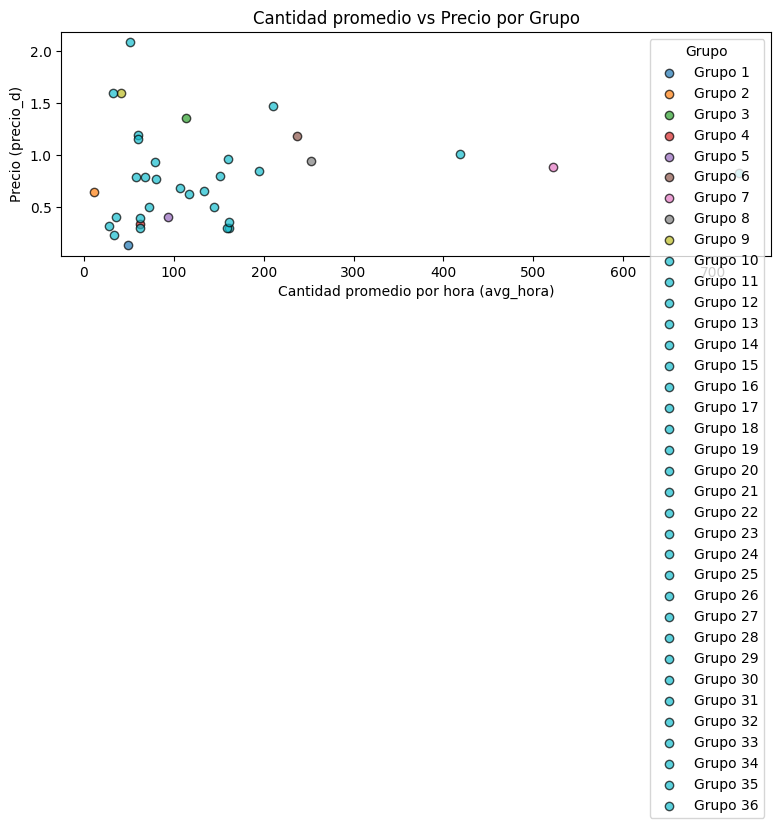

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular la media por planta dentro de cada grupo
df_mean = mean_por_planta_y_hora(df)

# Promedio horario total (h1-h24) → eje X
df_mean['avg_hora'] = df_mean[[f"h{i}" for i in range(1,25)]].mean(axis=1)

# Definir un colormap para 10 grupos
cmap = plt.get_cmap('tab10')  # 10 colores distintos
grupos_unicos = sorted(df_mean['Grupo'].unique())
colores = {g: cmap(i) for i, g in enumerate(grupos_unicos)}

plt.figure(figsize=(8,6))
for g in grupos_unicos:
    sub = df_mean[df_mean['Grupo'] == g]
    plt.scatter(
        sub['avg_hora'],
        sub['precio_d'],
        c=[colores[g]],
        label=f'Grupo {g}',
        alpha=0.7,
        edgecolors='k'
    )

plt.xlabel('Cantidad promedio por hora (avg_hora)')
plt.ylabel('Precio (precio_d)')
plt.title('Cantidad promedio vs Precio por Grupo')
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()



In [31]:
phi_by_plant = sample_day_batches_phi(
  df,
  H=H,
  seed=seed,
  day_col="Fecha",
  id_col="id_planta",
  phi_col="phi",
  price_col="precio_d",
  plant_ids=plant_ids,
  replace=True,
  min_active_plants=1,
  pick="random",
)

In [32]:


# 1) inferir input_dim desde obs_batch_by_pid
sample_obs = np.asarray(next(iter(phi_by_plant.values())))
input_dim = 1 if sample_obs.ndim == 1 else int(sample_obs.shape[1])

# 2) volver a correr el entry point con input_dim consistente
policies_group = policies_and_beta_profile_grouped(
    t=0,
    df=df,                      # df con columna "Grupo"
    obs_batch_by_pid=phi_by_plant,
    id_col="id_planta",
    grupo_col="Grupo",
    phi_col="phi",
    input_dim=input_dim,        # <- 24 si obs es (H,24)
    hidden=(10,10) ,
    device="auto",
    enforce_beta_ge_phi=True,
    min_margin=1e-6,
    floor_mode="max",
)

In [33]:
df=df.sort_values(["Fecha", "id_planta"]).reset_index(drop=True)
# 1) corre NPGA
theta_last_by_gid, nets_last_by_gid, Beta_last, eq_list_last, hist = npga_fit_by_group(
    df=df,
    theta_init_by_gid=policies_group["theta_by_gid"],
    obs_batch_by_pid=phi_by_plant,
    phi_batch_by_pid=phi_by_plant,
    pids=policies_group["pids"],
    compute_equilibrio_dispatch=compute_equilibrio_dispatch,
    joint_utility_from_eq_list=joint_utility_from_eq_list,
    T=T, P=P, sigma=sigma, eta=eta,
    pricing=pricing,
    unmet_price="max_accepted",
    device="auto",
)
# 2) crea 'out' compatible con extract_npga_panel_df
out = {
    "pricing": pricing,
    "pids": policies_group["pids"],
    "theta_last_by_gid": theta_last_by_gid,
    "nets_last_by_gid": nets_last_by_gid,
    "Beta_last": Beta_last,

    # aliases de compatibilidad para código viejo
    "theta_best_by_gid": theta_last_by_gid,
    "nets_best_by_gid": nets_last_by_gid,
    "Beta_best": Beta_last,

    "history": {
        "eq_list": eq_list_last,
        "phi_batch": phi_by_plant,
        "Beta": [Beta_last],
        "trace": hist,
    }
}



NPGA (t): 100%|██████████| 11/11 [52:07<00:00, 284.35s/it, U_mean=1.03e+04] 


## SAVE

In [34]:
import numpy as np
import pandas as pd


def extract_npga_panel_df(
    out: dict,
    *,
    qty_key: str = "cantidades_despachadas",
    price_key: str = "precio24",
    bid_key: str = "beta",
    phi_key: str = "phi_batch",
    eq_key: str = "eq_list",
    phi_reduce: str = "max",   # si phi[h,:] no es 24: "max" o "mean"
) -> pd.DataFrame:
    """
    Construye un panel a nivel (t, h, id_planta):
      columnas: id_planta, t, h, bid, cantidades_despachadas, precio24, phi

    Convención (según tu ejemplo):
      - out['history']['eq_list'][h] es un dict de un escenario (batch h),
        con keys globales ('I','demanda','price24',...) y keys por planta (1..I).
      - out['history']['phi_batch'][pid] es un array (H,24) (o (H,) o (H,d)).
        Para (pid,h) tomas phi_arr[h,:] (o repites/colapsas si no es 24).
    """
    if "history" not in out or out["history"] is None:
        raise KeyError("out no tiene 'history'")

    hist = out["history"]
    if eq_key not in hist:
        raise KeyError(f"out['history'] no tiene '{eq_key}'")
    if phi_key not in hist:
        raise KeyError(f"out['history'] no tiene '{phi_key}'")

    eq_hist = hist[eq_key]
    phi_hist = hist[phi_key]

    # pids (si no está, intenta leerlo del eq[ 'I' ])
    pids = list(out.get("pids", []))
    if not pids:
        # intenta inferir desde el primer eq
        if isinstance(eq_hist, (list, tuple)) and len(eq_hist) > 0 and isinstance(eq_hist[0], dict) and "I" in eq_hist[0]:
            pids = [int(x) for x in np.asarray(eq_hist[0]["I"]).reshape(-1).tolist()]
        else:
            raise KeyError("No encuentro out['pids'] y no pude inferir pids desde eq['I'].")

    I = len(pids)
    pid_to_j = {pid: j for j, pid in enumerate(pids)}
    try:
        max_pid = int(np.max([int(p) for p in pids]))
    except Exception:
        max_pid = None

    def _get_key_like(d: dict, key):
        if key in d:
            return d[key]
        try:
            ik = int(key)
            if ik in d:
                return d[ik]
        except Exception:
            pass
        sk = str(key)
        if sk in d:
            return d[sk]
        raise KeyError(f"key={key} no está. keys ejemplo={list(d.keys())[:10]}")

    def _ensure_24(x):
        a = np.asarray(x, dtype=float).reshape(-1)
        if a.size == 24:
            return a
        if a.size == 1:
            return np.repeat(float(a[0]), 24)
        raise ValueError(f"vector size {a.size}, esperaba 24 o 1")

    def _phi24_from_arr(A, h_idx: int):
        A = np.asarray(A, dtype=float)
        if A.ndim == 1:
            # (H,)
            return np.repeat(float(A[h_idx]), 24)
        if A.ndim == 2 and A.shape[1] == 24:
            # (H,24)
            return A[h_idx, :].astype(float)
        if A.ndim == 2:
            # (H,d) con d!=24: colapsa a escalar y repite
            v = A[h_idx, :].astype(float)
            if phi_reduce == "mean":
                return np.repeat(float(np.nanmean(v)), 24)
            return np.repeat(float(np.nanmax(v)), 24)
        raise ValueError(f"phi shape no soportado: {A.shape}")

    def _get_phi_arr_for_pid(phi_container, pid, j):
        # Caso A: dict pid -> array
        if isinstance(phi_container, dict):
            return _get_key_like(phi_container, pid)

        A = np.asarray(phi_container)

        # Caso B: array/list indexado por planta en eje 0
        # Heurística de índice:
        #   - si eje0 == I: usa j
        #   - si pid es int y eje0 > max_pid: usa pid
        #   - fallback: usa j
        pid_idx = j
        try:
            pid_int = int(pid)
            if A.ndim >= 1 and A.shape[0] != I and max_pid is not None and A.shape[0] >= max_pid + 1:
                pid_idx = pid_int
        except Exception:
            pid_idx = j

        if A.ndim >= 1 and A.shape[0] == I:
            pid_idx = j

        return A[pid_idx]

    # Normaliza eq_hist a iteración (t,h,eq_dict)
    def _iter_eq(eq_hist_obj):
        # Caso 1: eq_hist es lista de escenarios (H)  -> t=0
        if isinstance(eq_hist_obj, (list, tuple)):
            if len(eq_hist_obj) == 0:
                return
            # si el primer elemento es dict por planta (como tu ejemplo), entonces es lista por h
            if isinstance(eq_hist_obj[0], dict) and any((pid in eq_hist_obj[0]) or (str(pid) in eq_hist_obj[0]) for pid in pids):
                for h, eq in enumerate(eq_hist_obj):
                    yield 0, h, eq
                return
            # si es lista por t y cada t contiene lista/dict de h
            for t, eq_t in enumerate(eq_hist_obj):
                if isinstance(eq_t, (list, tuple)):
                    for h, eq in enumerate(eq_t):
                        yield t, h, eq
                elif isinstance(eq_t, dict):
                    # dict h->eq o dict por planta (single h)
                    if any((pid in eq_t) or (str(pid) in eq_t) for pid in pids):
                        yield t, 0, eq_t
                    else:
                        for h, eq in enumerate(eq_t.values()):
                            yield t, h, eq
                else:
                    raise TypeError(f"eq_list[{t}] no soportado: {type(eq_t)}")
            return

        # Caso 2: eq_hist es dict (por t o por h)
        if isinstance(eq_hist_obj, dict):
            # si parece dict por planta (single eq)
            if any((pid in eq_hist_obj) or (str(pid) in eq_hist_obj) for pid in pids):
                yield 0, 0, eq_hist_obj
                return
            # si es dict por t -> ...
            for t_key, eq_t in eq_hist_obj.items():
                t = int(t_key) if str(t_key).isdigit() else t_key
                if isinstance(eq_t, (list, tuple)):
                    for h, eq in enumerate(eq_t):
                        yield t, h, eq
                elif isinstance(eq_t, dict):
                    if any((pid in eq_t) or (str(pid) in eq_t) for pid in pids):
                        yield t, 0, eq_t
                    else:
                        for h, eq in enumerate(eq_t.values()):
                            yield t, h, eq
                else:
                    raise TypeError(f"eq_list[{t_key}] no soportado: {type(eq_t)}")
            return

        raise TypeError(f"eq_list no soportado: {type(eq_hist_obj)}")

    rows = []
    for t, h, eq in _iter_eq(eq_hist):
        for pid in pids:
            eq_pid = _get_key_like(eq, pid)

            bid = float(eq_pid[bid_key]) if bid_key in eq_pid else np.nan
            q24 = _ensure_24(eq_pid[qty_key])
            p24 = _ensure_24(eq_pid[price_key])

            phi_arr_pid = _get_phi_arr_for_pid(phi_hist, pid, pid_to_j[pid])
            phi24 = _phi24_from_arr(phi_arr_pid, h)

            rows.append({
                "id_planta": int(pid) if str(pid).isdigit() else pid,
                "t": int(t) if str(t).isdigit() else t,
                "h": int(h),
                "bid": float(bid),
                "cantidades_despachadas": q24.tolist(),
                "precio24": p24.tolist(),
                "phi": phi24.tolist(),
            })

    return pd.DataFrame(rows)


In [35]:
import os
import pandas as pd


import os
import pandas as pd


def export_panel_to_drive(
    *,
    panel: pd.DataFrame,
    out_dir: str,
    fname_prefix: str,
    fname_sufix: str
) -> dict:
    os.makedirs(out_dir, exist_ok=True)

    panel_path = os.path.join(out_dir, f"panel_{fname_prefix}_{fname_sufix}.csv")
    panel.to_csv(panel_path, index=False)

    return {"panel_path": panel_path}




ejecutar save

In [36]:
import torch
out_dir=f"{G}redespromedio"

if pricing=='uniform':
  # Uniform
  panel_uniform = extract_npga_panel_df(out)
  export_panel_to_drive(panel=panel_uniform, out_dir=out_dir, fname_prefix="uniform", fname_sufix=T)
  

if pricing=='pay_as_bid':
  panel_pay_as_bid = extract_npga_panel_df(out)
  export_panel_to_drive(panel=panel_pay_as_bid, out_dir=out_dir, fname_prefix="pay_as_bid", fname_sufix=T)
   

In [37]:
import torch

path = f"{out_dir}/nets_best_by_gid_{pricing}_{T}.pt"

to_save = {
    int(gid): net.state_dict()
    for gid, net in out["nets_last_by_gid"].items()
}

torch.save(to_save, path)



## utilidad

In [38]:
import pandas as pd

hist = out["history"]["trace"] 
filas = []

for entrada in hist:
    t = entrada["t"]
    
    fila = {"t": t}
    
    for rep in entrada["reps"]:
        grupo = rep["grupo"]
        fila[f"grupo{grupo}"] = rep["u_new_group"]   # puedes cambiar a u_base
    
    filas.append(fila)

df = pd.DataFrame(filas)

print(df)

     t       grupo1     grupo2      grupo3       grupo4       grupo5  grupo6  \
0    0  1420.565987  78.832462  299.825691  1427.559479  1447.255498     0.0   
1    1   563.148593  12.861786   61.069138   277.454355   577.525618     0.0   
2    2   219.288039   0.178056    3.902188    17.338545   251.495207     0.0   
3    3   111.190006   0.178012    2.956049    12.230914   131.405562     0.0   
4    4   214.332028   0.177974    2.658508    10.925331   130.715294     0.0   
5    5   261.756098   0.088966    2.503545    10.154341   109.822778     0.0   
6    6   336.545892   0.000000    1.461385     8.264061   156.547714     0.0   
7    7   351.612699   0.000000    1.460257     8.231303   204.710387     0.0   
8    8   372.620704   0.000000    1.326857     7.624694   203.974991     0.0   
9    9   365.837451   0.000000    1.326101     7.606974   218.444534     0.0   
10  10   384.829497   0.000000    1.325304     7.583818   263.070784     0.0   

         grupo7      grupo8    grupo9  

In [39]:
df.to_csv(f"{out_dir}/u_group_by_t_{pricing}_{T}.csv", index=False)

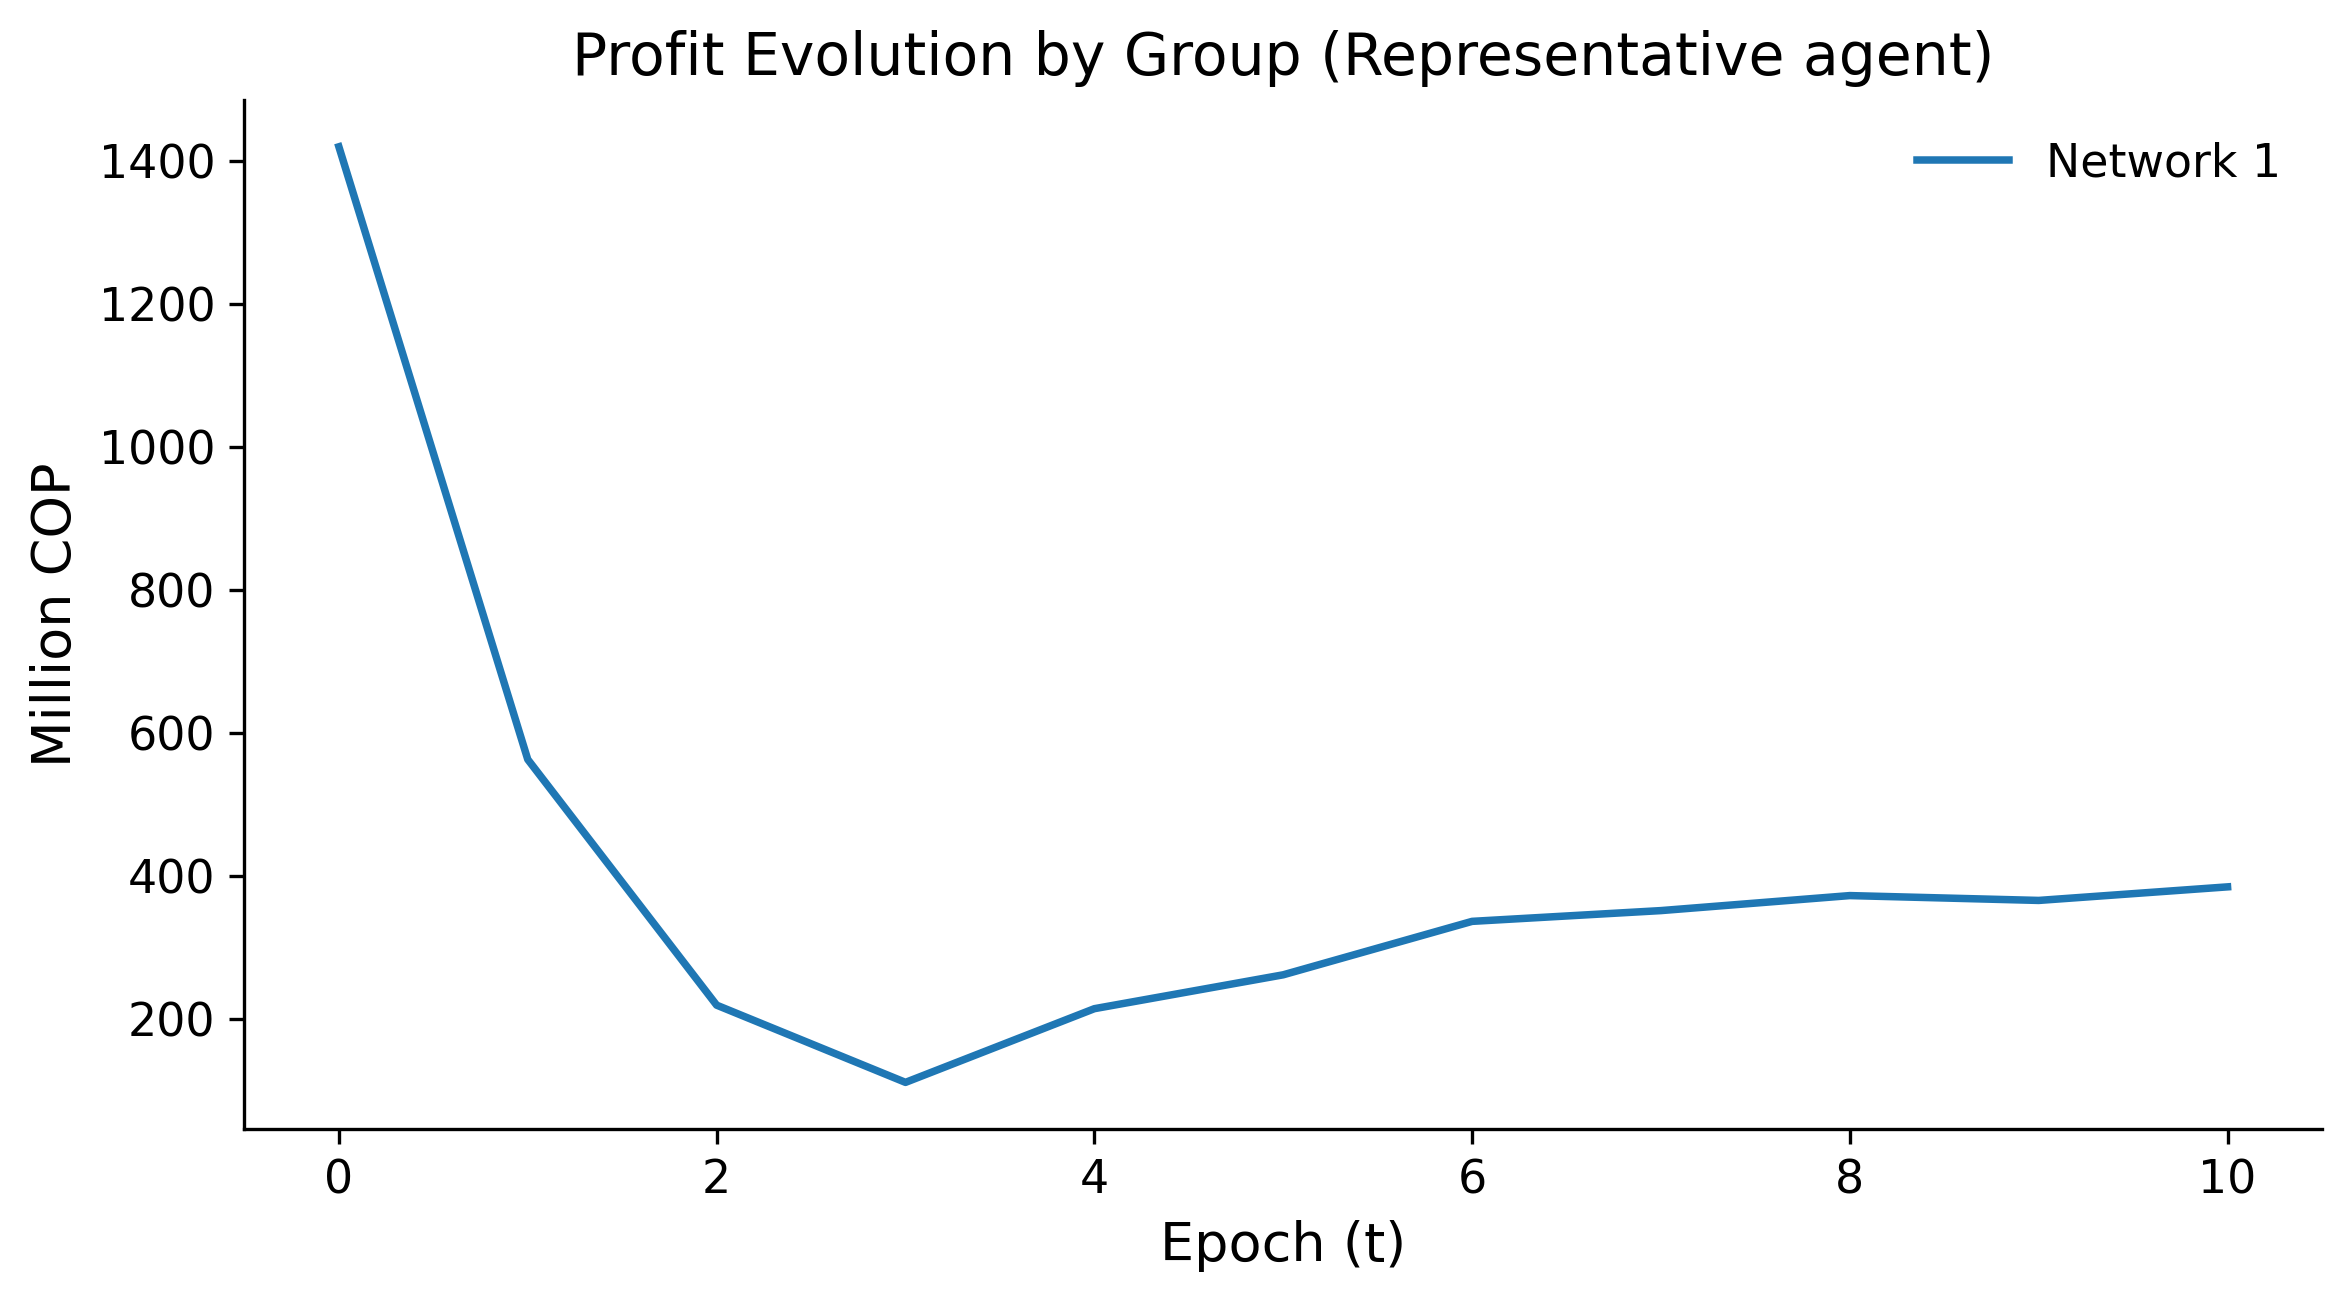

In [40]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Paper-style settings ---
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plt.figure(figsize=(8, 4.5), dpi=300)

# Plot lines with professional styling
plt.plot(df["t"], df["grupo1"], label="Network 1", linewidth=1.8)

# Axis labels
plt.xlabel("Epoch (t)")
plt.ylabel("Million COP")
plt.title("Profit Evolution by Group (Representative agent)")

# Remove grid for cleaner paper style
plt.grid(False)

# Legend
plt.legend(frameon=False)

plt.tight_layout()

# Optional: save in high quality for paper
# plt.savefig("figure_groups.png", dpi=300, bbox_inches="tight")

plt.show()

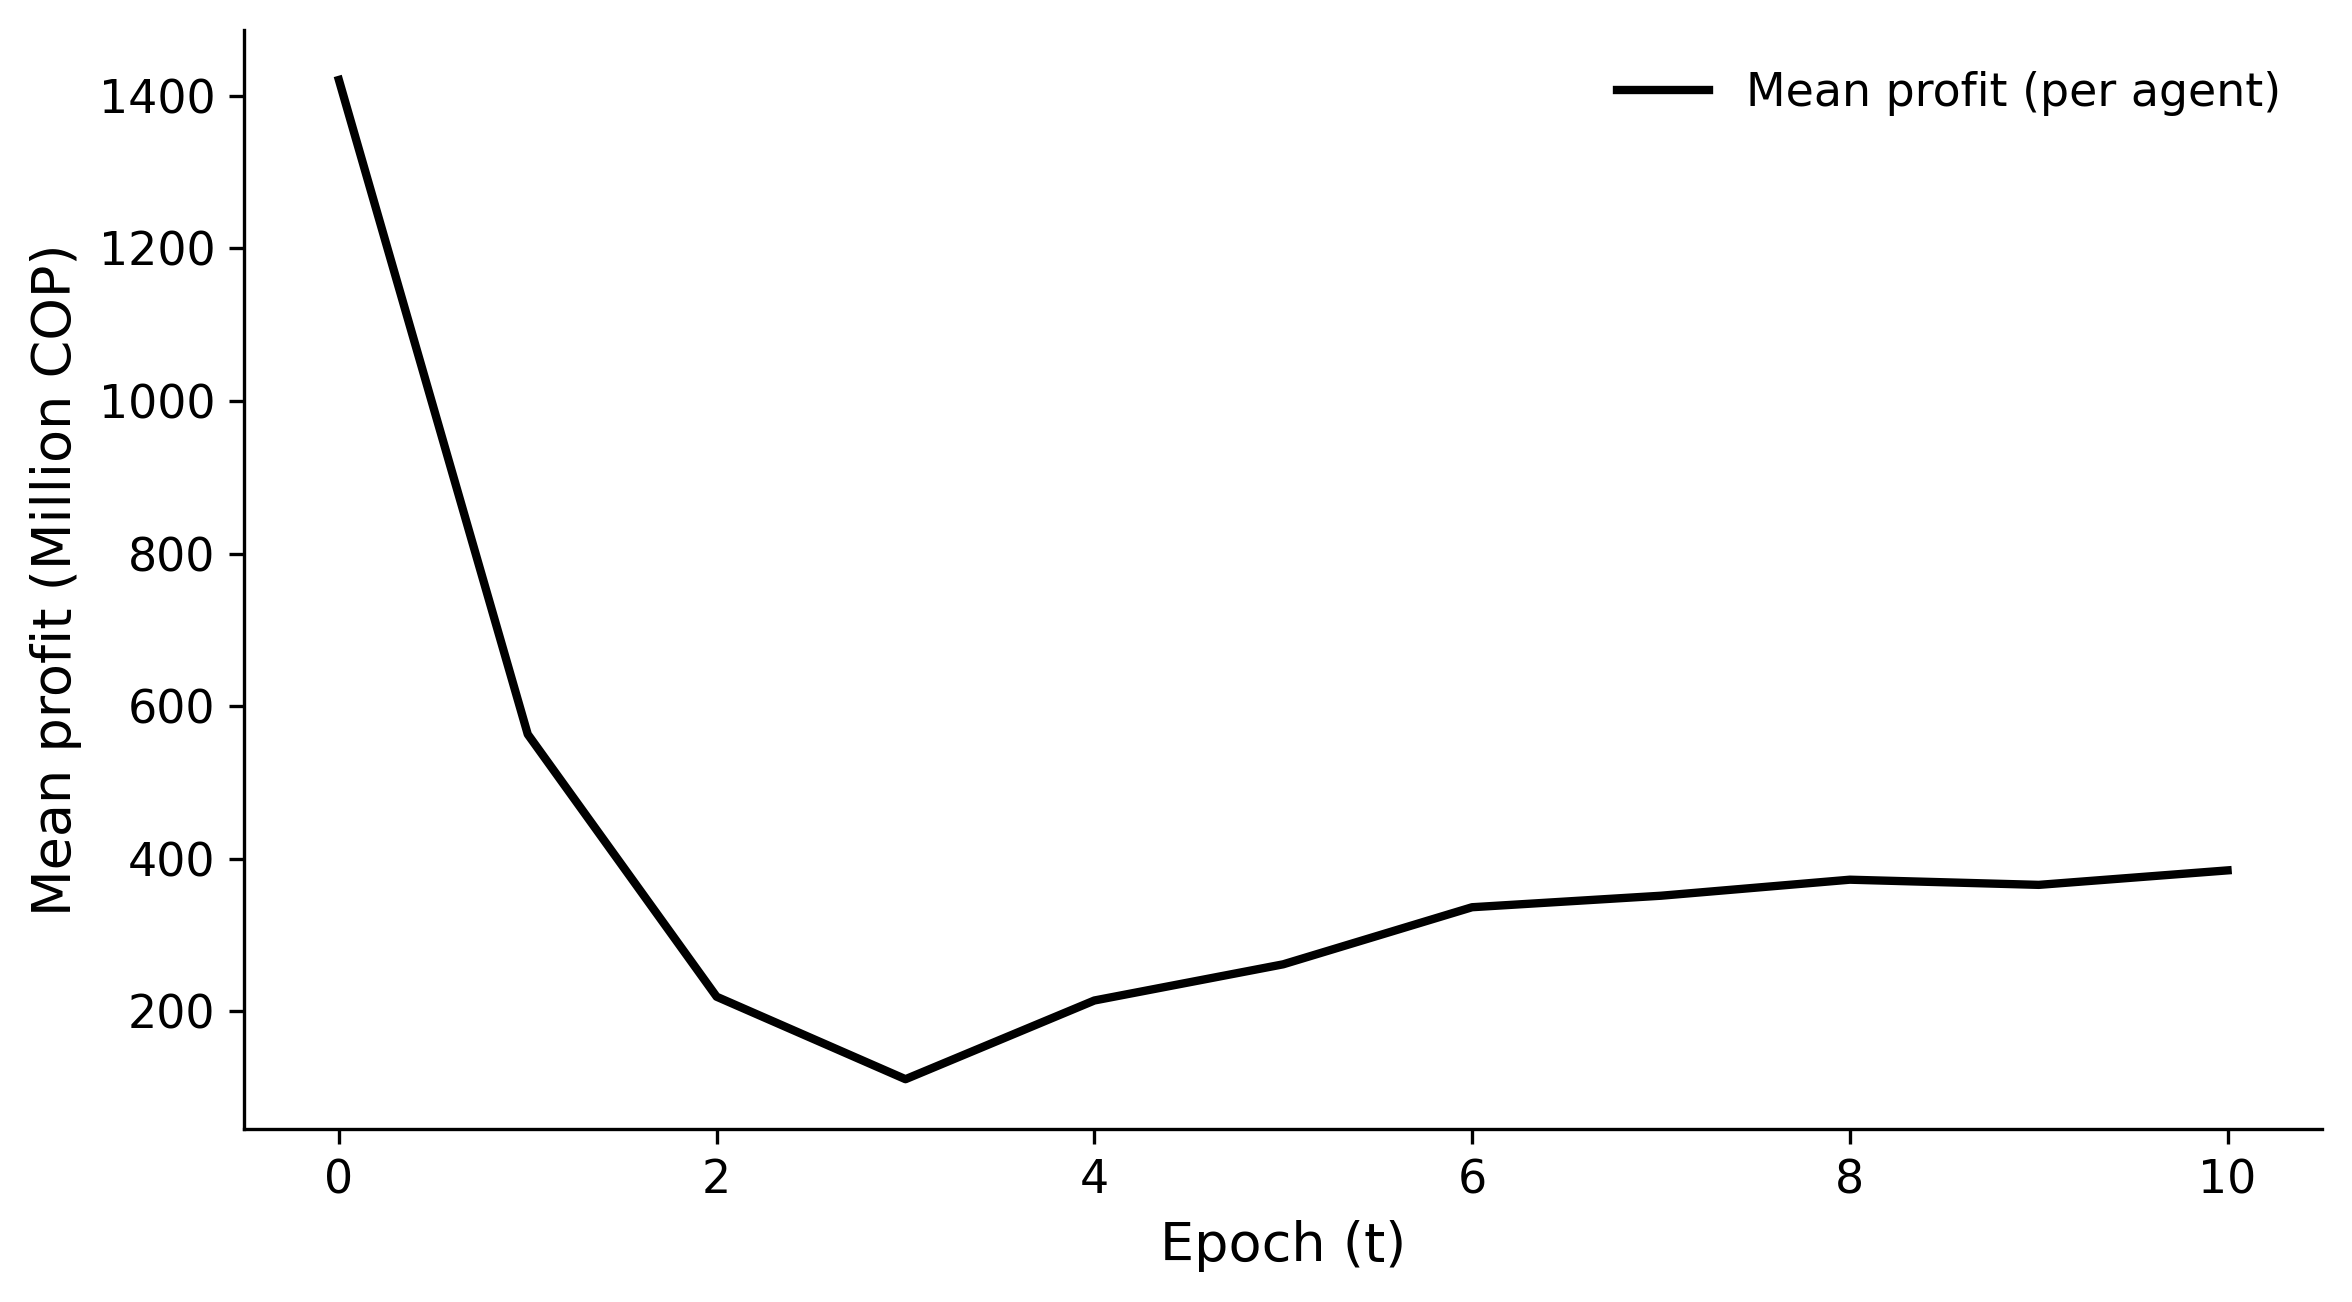

In [41]:
# Calculate mean utility across groups for each t
df["mean_utility"] = df[["grupo1"]].mean(axis=1)

import matplotlib.pyplot as plt
import matplotlib as mpl

# Paper-style formatting
mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plt.figure(figsize=(8,4.5), dpi=300)

plt.plot(df["t"], df["mean_utility"], 
         linewidth=2, color="black", label="Mean profit (per agent)")

plt.xlabel("Epoch (t)")
plt.ylabel("Mean profit (Million COP)")
plt.legend(frameon=False)
plt.grid(False)

plt.tight_layout()
plt.show()